In [ ]:
import numpy as np
import rasterio
from rasterio.windows import Window
from rasterio.mask import mask
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from typing import Tuple, List, Dict
from tqdm import tqdm
import os
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.ndimage import zoom
import numpy as np
import numpy as np
import random
import json
from pathlib import Path
from typing import Dict, List, Tuple
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from typing import Dict, Tuple
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
from pathlib import Path

from data_loader import ( load_dem, load_infiltration_map, load_landuse_map, get_raster_stats, print_raster_stats,
                            load_all_rainfall_scenarios, get_rainfall_stats, print_rainfall_stats, load_all_flood_maps)
from data_loader import (visualize_raster, visualize_flood_maps_grid)
from data_preprocessing import (normalize_dem, normalize_infiltration, normalize_landuse, handle_nodata )
from flood_maps import (FLOOD_CLASSES, reconstruct_map_from_patches, categorize_all_flood_maps_patch, visualize_all_categorized_maps)
from vit_architecture import ViTFloodClassifier, get_model_summary
from model_config import (create_small_model, create_small_regularized_model, compare_all_configurations, print_model_details)
from training import train_kfold, calculate_class_weights
from testing import (evaluate_test_scenarios, plot_confusion_matrix, plot_scenario_comparison, reconstruct_test_map_from_patches)

RANDOM_SEED = 42
NUM_TRAIN = 15
NUM_TEST = 5
NUM_SCENARIO = 50
PATCH_SIZE = 4

# Hyperparameters
BATCH_SIZE = 64
NUM_WORKERS = 4     
PIN_MEMORY = False 

colors = [FLOOD_CLASSES[i]['color'] for i in range(5)]
cmap = ListedColormap(colors)
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
norm = BoundaryNorm(bounds, cmap.N)


''' PATCH_CLASSES_RESILIENCY = { 
    0: (0.0, 0.32),   
    1: (0.32, 0.48),  
    2: (0.48, 0.97),   
    3: (0.97, 1.46),   
    4: (1.46, float('inf'))
}

PATCH_CLASSES_SUSCEPTIBILITY = {
    0: (0.0, 0.15),      
    1: (0.15, 0.24),           
    2: (0.24, 0.46),            
    3: (0.46, 0.68),           
    4: (0.68, float('inf'))       
}
'''


" PATCH_CLASSES_RESILIENCY = { \n    0: (0.0, 0.32),   \n    1: (0.32, 0.48),  \n    2: (0.48, 0.97),   \n    3: (0.97, 1.46),   \n    4: (1.46, float('inf'))\n}\n\nPATCH_CLASSES_SUSCEPTIBILITY = {\n    0: (0.0, 0.15),      \n    1: (0.15, 0.24),           \n    2: (0.24, 0.46),            \n    3: (0.46, 0.68),           \n    4: (0.68, float('inf'))       \n}\n"

In [2]:
repo_root = os.getcwd()
gmm_path = os.path.join(repo_root, "COP-30m-GMM")
manila_path = os.path.join(repo_root, "COP-30m-ManilaOnly")
rs_path = os.path.join(repo_root, "rc_randomized_mm_hr_scenarios")
train_rs_path = os.path.join(rs_path, "train")
test_rs_path = os.path.join(rs_path, "validation")
# test_rs_path = os.path.join(rs_path, "test")

# Loading data

In [3]:
# Load DEM
print("\n--- Loading DEM ---")
dem_path = os.path.join(manila_path, "by_box", "manila_bbox_dem_cop.tif")
if os.path.exists(dem_path):
    dem_data, dem_meta = load_dem(dem_path)
    dem_stats = get_raster_stats(dem_data, "DEM")
    print_raster_stats(dem_stats)
else:
    print(f"WARNING: DEM file not found at {dem_path}")
    dem_data = None



--- Loading DEM ---
DEM loaded: shape (320, 320), dtype float32

Statistics for: DEM
Shape:         (320, 320)
Dtype:         float32
Min value:     -9.1316
Max value:     46.7424
Mean value:    6.1565
Std dev:       5.5713
Valid pixels:  102,400 / 102,400



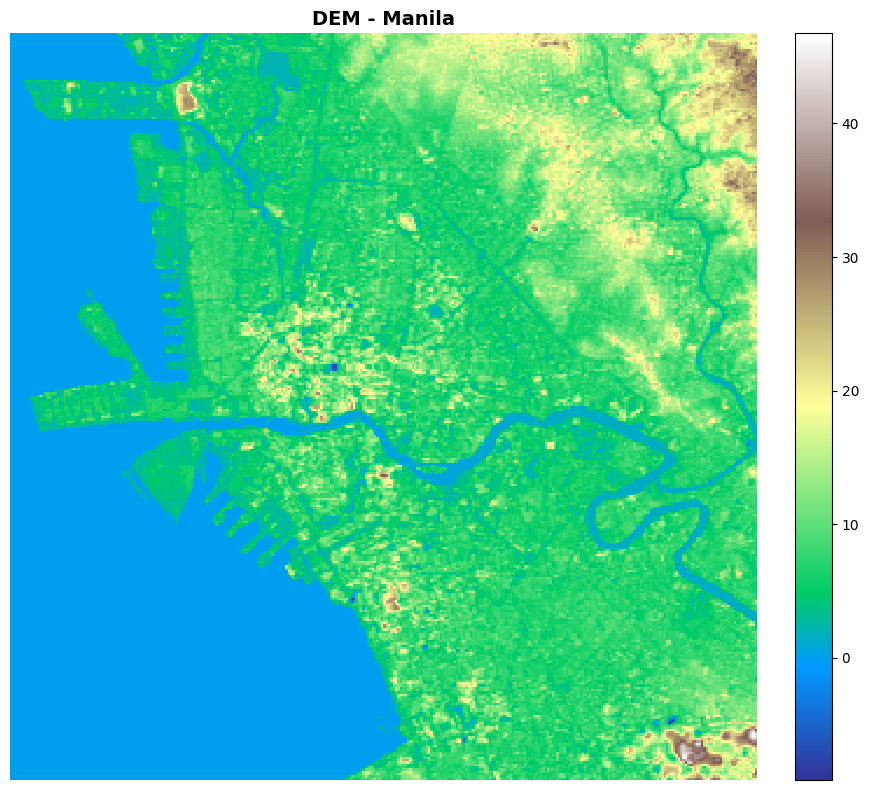

In [4]:
fig1 = visualize_raster(dem_data, title="DEM - Manila", cmap='terrain')

In [5]:
# Load Infiltration Map
print("\n--- Loading Infiltration Map ---")
infilt_path = os.path.join(manila_path, "by_box", "GM_Infilt_Manila_box.tif")
if os.path.exists(infilt_path):
    infilt_data, infilt_meta = load_infiltration_map(infilt_path)
    infilt_stats = get_raster_stats(infilt_data, "Infiltration Map")
    print_raster_stats(infilt_stats)
else:
    print(f"WARNING: Infiltration file not found at {infilt_path}")
    infilt_data = None


--- Loading Infiltration Map ---
Infiltration map loaded: shape (320, 320), dtype float64

Statistics for: Infiltration Map
Shape:         (320, 320)
Dtype:         float64
Min value:     0.0000
Max value:     2.7687
Mean value:    0.0127
Std dev:       0.1795
Valid pixels:  102,400 / 102,400



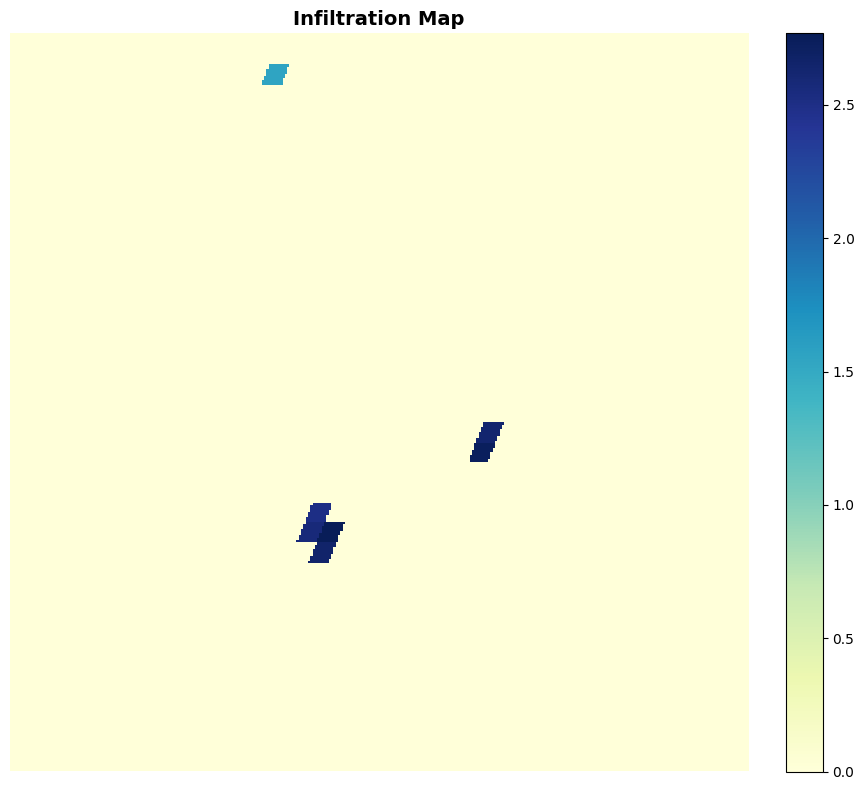

In [6]:
fig2 = visualize_raster(infilt_data, title="Infiltration Map", cmap='YlGnBu')

In [7]:
# Load Landuse Map
print("\n--- Loading Landuse Map ---")
landuse_path = os.path.join(manila_path, "by_box", "GM_LU_Manila_box.tif")
if os.path.exists(landuse_path):
    landuse_data, landuse_meta = load_landuse_map(landuse_path)
    landuse_stats = get_raster_stats(landuse_data, "Landuse Map")
    print_raster_stats(landuse_stats)
else:
    print(f"WARNING: Landuse file not found at {landuse_path}")
    landuse_data = None



--- Loading Landuse Map ---
Landuse map loaded: shape (320, 320), dtype float64

Statistics for: Landuse Map
Shape:         (320, 320)
Dtype:         float64
Min value:     1.0000
Max value:     11.0000
Mean value:    5.7151
Std dev:       1.6457
Valid pixels:  102,400 / 102,400



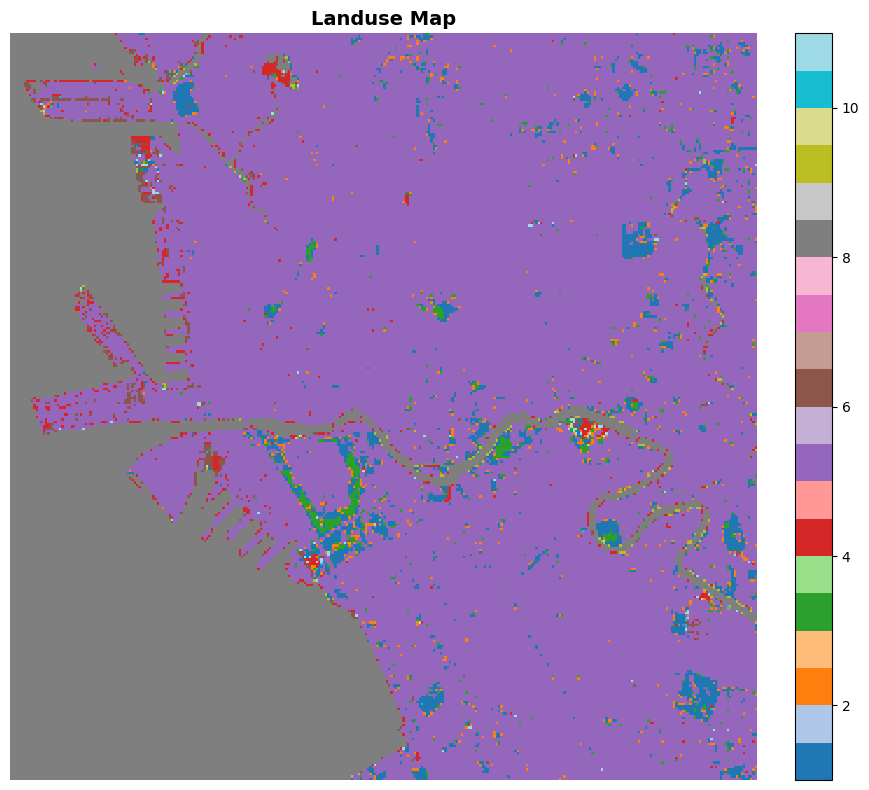

In [8]:
fig3 = visualize_raster(landuse_data, title="Landuse Map", cmap='tab20')

In [9]:
# Load all flood maps
print("\n--- Loading Flood Maps (Ground Truth) ---")
fm_path = os.path.join(manila_path, "by_box")
flood_maps, flood_metadata = load_all_flood_maps(fm_path, num_scenarios=NUM_SCENARIO)

if len(flood_maps) > 0:
    print(f"\nFlood maps successfully loaded: {len(flood_maps)}")
    
    if len(flood_maps) >= NUM_SCENARIO:
        flood_stats = get_raster_stats(flood_maps[-1], "Flood Map RS20")
else:
    print("WARNING: No flood maps loaded!")


--- Loading Flood Maps (Ground Truth) ---
Flood map RS1 loaded: shape (320, 320), dtype float64
Flood map RS2 loaded: shape (320, 320), dtype float64
Flood map RS3 loaded: shape (320, 320), dtype float64
Flood map RS4 loaded: shape (320, 320), dtype float64
Flood map RS5 loaded: shape (320, 320), dtype float64
Flood map RS6 loaded: shape (320, 320), dtype float64
Flood map RS7 loaded: shape (320, 320), dtype float64
Flood map RS8 loaded: shape (320, 320), dtype float64
Flood map RS9 loaded: shape (320, 320), dtype float64
Flood map RS10 loaded: shape (320, 320), dtype float64
Flood map RS11 loaded: shape (320, 320), dtype float64
Flood map RS12 loaded: shape (320, 320), dtype float64
Flood map RS13 loaded: shape (320, 320), dtype float64
Flood map RS14 loaded: shape (320, 320), dtype float64
Flood map RS15 loaded: shape (320, 320), dtype float64
Flood map RS16 loaded: shape (320, 320), dtype float64
Flood map RS17 loaded: shape (320, 320), dtype float64
Flood map RS18 loaded: shape (3

In [10]:
print_raster_stats(flood_stats)


Statistics for: Flood Map RS20
Shape:         (320, 320)
Dtype:         float64
Min value:     0.0000
Max value:     3.8214
Mean value:    0.1406
Std dev:       0.2650
Valid pixels:  102,400 / 102,400



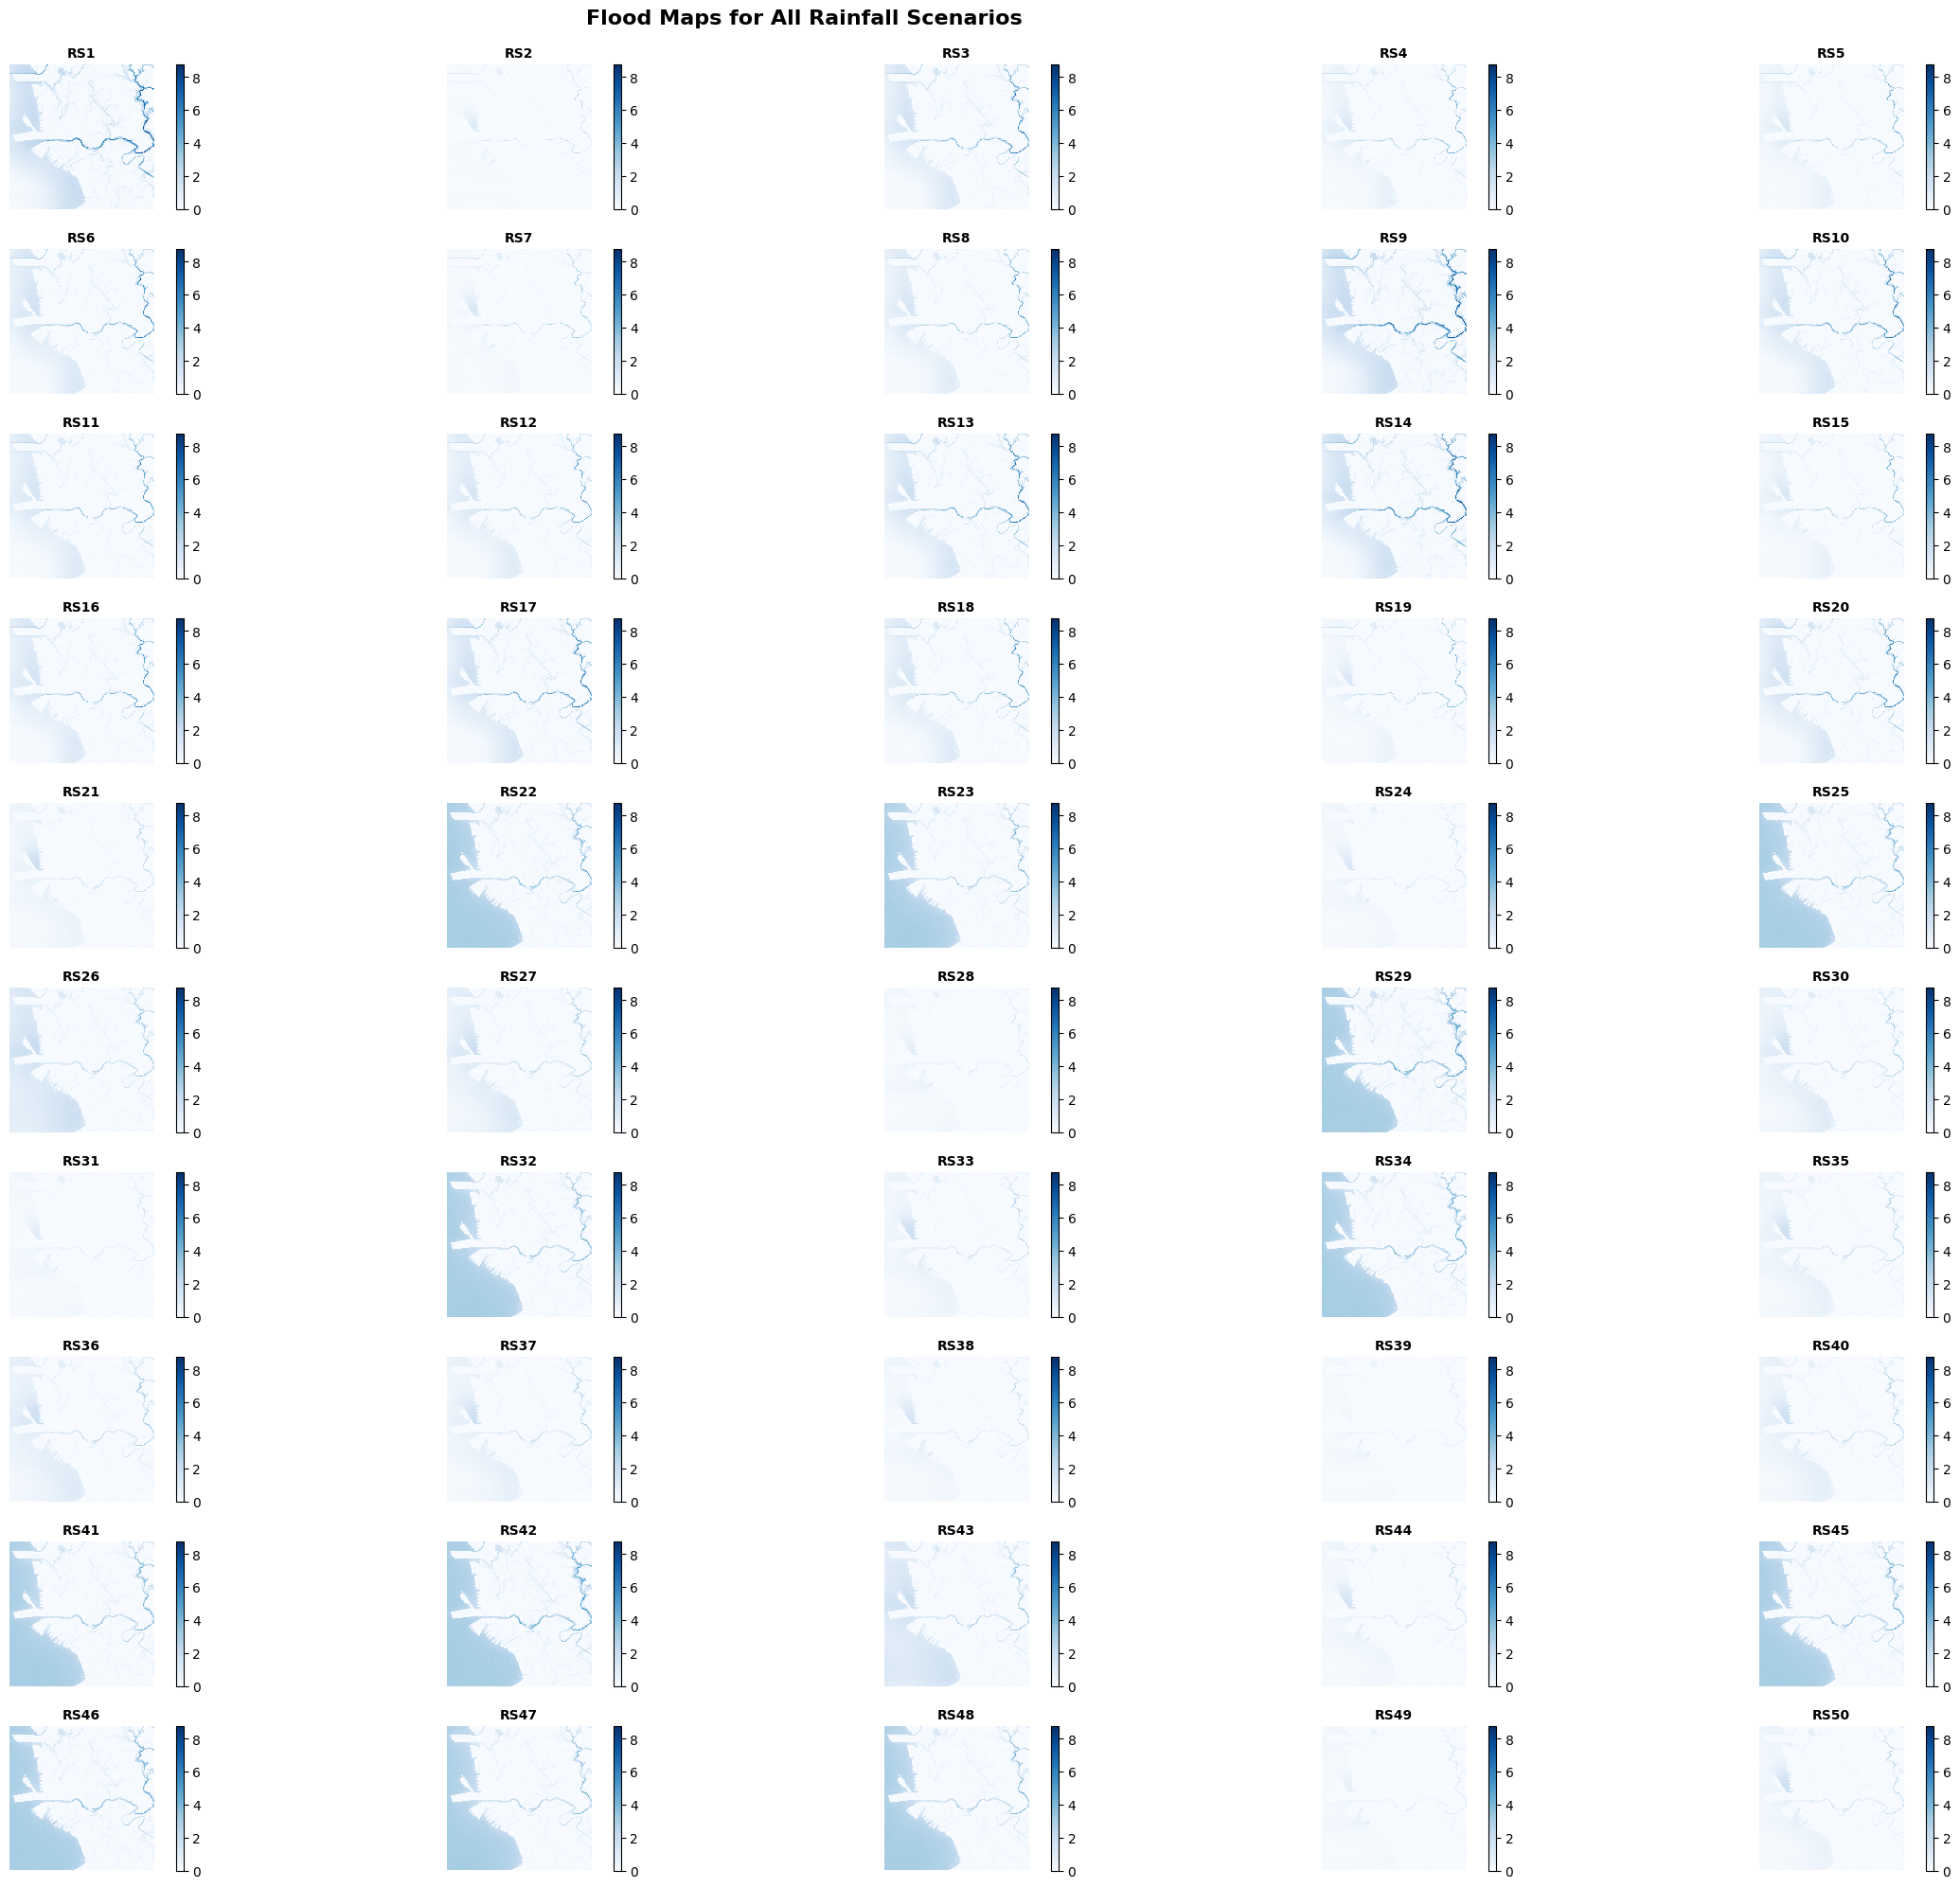

In [11]:
fig4 = visualize_flood_maps_grid(flood_maps=flood_maps,scenario_ids=list(range(1, 51)),figsize=(25, 20),ncols=5,cmap='Blues')
#plt.show()

In [12]:
from RC_randomizer import split_rs_dataset #, split_rs_dataset_three_way

source = "mm_hr_scenarios"
output = "rc_randomized_mm_hr_scenarios"

split_rs_dataset(source_dir=source, output_dir=output)

Rainfall SC 1-10: 7 train | 3 validation
Rainfall SC 11-20: 7 train | 3 validation
Rainfall SC 21-30: 7 train | 3 validation
Rainfall SC 31-50: 14 train | 6 validation

70/30 split completed!


In [13]:
print("LOADING TRAINING RAINFALL SCENARIOS")
# Load rainfall scenarios
train_rainfall_scenarios = load_all_rainfall_scenarios(train_rs_path)

if len(train_rainfall_scenarios) > 0:
    print(f"\nRainfall scenarios successfully loaded: {len(train_rainfall_scenarios)}")
    
    if len(train_rainfall_scenarios) >= NUM_SCENARIO:
        rain_stats = get_rainfall_stats(train_rainfall_scenarios[-1], scenario_id=50)
else:
    print("WARNING: No rainfall scenarios loaded!")

LOADING TRAINING RAINFALL SCENARIOS
Rainfall Scenario 12 loaded: 13 time steps
Rainfall Scenario 13 loaded: 13 time steps
Rainfall Scenario 14 loaded: 13 time steps
Rainfall Scenario 15 loaded: 13 time steps
Rainfall Scenario 16 loaded: 13 time steps
Rainfall Scenario 18 loaded: 13 time steps
Rainfall Scenario 19 loaded: 13 time steps
Rainfall Scenario 21 loaded: 13 time steps
Rainfall Scenario 22 loaded: 13 time steps
Rainfall Scenario 23 loaded: 13 time steps
Rainfall Scenario 25 loaded: 13 time steps
Rainfall Scenario 26 loaded: 13 time steps
Rainfall Scenario 28 loaded: 13 time steps
Rainfall Scenario 2 loaded: 13 time steps
Rainfall Scenario 30 loaded: 13 time steps
Rainfall Scenario 31 loaded: 13 time steps
Rainfall Scenario 32 loaded: 13 time steps
Rainfall Scenario 33 loaded: 13 time steps
Rainfall Scenario 34 loaded: 13 time steps
Rainfall Scenario 36 loaded: 13 time steps
Rainfall Scenario 38 loaded: 13 time steps
Rainfall Scenario 3 loaded: 13 time steps
Rainfall Scenario 40

In [14]:
print("LOADING VALIDATION RAINFALL SCENARIOS")
# Load rainfall scenarios
test_rainfall_scenarios = load_all_rainfall_scenarios(test_rs_path)

if len(test_rainfall_scenarios) > 0:
    print(f"\nRainfall scenarios successfully loaded: {len(test_rainfall_scenarios)}")
    
    if len(test_rainfall_scenarios) >= NUM_SCENARIO:
        rain_stats = get_rainfall_stats(test_rainfall_scenarios[-1], scenario_id=50)
else:
    print("WARNING: No rainfall scenarios loaded!")

LOADING VALIDATION RAINFALL SCENARIOS
Rainfall Scenario 10 loaded: 13 time steps
Rainfall Scenario 11 loaded: 13 time steps
Rainfall Scenario 17 loaded: 13 time steps
Rainfall Scenario 1 loaded: 13 time steps
Rainfall Scenario 20 loaded: 13 time steps
Rainfall Scenario 24 loaded: 13 time steps
Rainfall Scenario 27 loaded: 13 time steps
Rainfall Scenario 29 loaded: 13 time steps
Rainfall Scenario 35 loaded: 13 time steps
Rainfall Scenario 37 loaded: 13 time steps
Rainfall Scenario 39 loaded: 13 time steps
Rainfall Scenario 41 loaded: 13 time steps
Rainfall Scenario 43 loaded: 13 time steps
Rainfall Scenario 44 loaded: 13 time steps
Rainfall Scenario 4 loaded: 13 time steps

Total rainfall scenarios loaded: 15

Rainfall scenarios successfully loaded: 15


# Data Preprocessing

## Handle NoData

In [15]:
print("\nProcessing DEM...")
dem_clean = handle_nodata(
    dem_data, 
    nodata_value=dem_meta.get('nodata'),
    fill_method='mean'  # Options: 'mean', 'median', 'zero', 'interpolate'
)
# Verify
# dem_clean_stats = get_raster_stats(dem_clean, "DEM (NoData Handled)")
# print_raster_stats(dem_clean_stats)


Processing DEM...

Handling NoData for Raster...
  NoData pixels: 0 / 102,400 (0.00%)
  ✓ No NoData values found


In [16]:
# 2. Handle NoData in Infiltration
print("\nProcessing Infiltration...")
infilt_clean = handle_nodata(
    infilt_data,
    nodata_value=infilt_meta.get('nodata'),
    fill_method='mean'  # Options: 'mean', 'median', 'zero', 'interpolate'
)

# Verify
# infilt_clean_stats = get_raster_stats(infilt_clean, "Infiltration (NoData Handled)")
# print_raster_stats(infilt_clean_stats)


Processing Infiltration...

Handling NoData for Raster...
  NoData pixels: 0 / 102,400 (0.00%)
  ✓ No NoData values found


In [17]:
# 3. Handle NoData in Landuse
print("\nProcessing Landuse...")
landuse_clean = handle_nodata(
    landuse_data,
    nodata_value=landuse_meta.get('nodata'),
    fill_method='interpolate'  # Interpolate is better for categorical data
)

# Verify
# landuse_clean_stats = get_raster_stats(landuse_clean, "Landuse (NoData Handled)")
# print_raster_stats(landuse_clean_stats)


Processing Landuse...

Handling NoData for Raster...
  NoData pixels: 0 / 102,400 (0.00%)
  ✓ No NoData values found


## Normalization

In [18]:
# Normalize DEM
print("\nNormalizing DEM...")
dem_normalized, dem_params = normalize_dem(dem_data, method='minmax')

print("\nReshaping DEM to 320×320...")
print(f"  Original shape: {dem_normalized.shape}")
zoom_factor_h = 320 / dem_normalized.shape[0] 
zoom_factor_w = 320 / dem_normalized.shape[1]  

# Resize using zoom
dem_normalized = zoom(dem_normalized, (zoom_factor_h, zoom_factor_w), order=1)  # order=1 for bilinear

print(f"  New shape: {dem_normalized.shape}")
print(f"  Value range: [{dem_normalized.min():.4f}, {dem_normalized.max():.4f}]")

dem_normalized, dem_params = normalize_dem(dem_normalized, method='minmax')
# Verify normalization
dem_norm_stats = get_raster_stats(dem_normalized, "DEM (Normalized)")
print_raster_stats(dem_norm_stats)


Normalizing DEM...
DEM normalized (min-max): [-9.1316, 46.7424] -> [0.0, 1.0]

Reshaping DEM to 320×320...
  Original shape: (320, 320)
  New shape: (320, 320)
  Value range: [0.0000, 1.0000]
DEM normalized (min-max): [0.0000, 1.0000] -> [0.0, 1.0]

Statistics for: DEM (Normalized)
Shape:         (320, 320)
Dtype:         float32
Min value:     0.0000
Max value:     1.0000
Mean value:    0.2736
Std dev:       0.0997
Valid pixels:  102,400 / 102,400



In [19]:
# Normalize Infiltration
print("\nNormalizing Infiltration...")
infilt_normalized, infilt_params = normalize_infiltration(infilt_data)
# Verify normalization
infilt_norm_stats = get_raster_stats(infilt_normalized, "Infiltration (Normalized)")
print_raster_stats(infilt_norm_stats)


Normalizing Infiltration...
Infiltration normalized (min-max): [0.0000, 2.7687] -> [0.0, 1.0]

Statistics for: Infiltration (Normalized)
Shape:         (320, 320)
Dtype:         float64
Min value:     0.0000
Max value:     1.0000
Mean value:    0.0046
Std dev:       0.0648
Valid pixels:  102,400 / 102,400



In [20]:
# Normalize Landuse
print("\nNormalizing Landuse...")
landuse_normalized, landuse_params = normalize_landuse(landuse_data, method='minmax')
# Verify normalization
landuse_norm_stats = get_raster_stats(landuse_normalized, "Landuse (Normalized)")
print_raster_stats(landuse_norm_stats)


Normalizing Landuse...
Landuse normalized (min-max): [1.0000, 11.0000] -> [0.0, 1.0]

Statistics for: Landuse (Normalized)
Shape:         (320, 320)
Dtype:         float64
Min value:     0.0000
Max value:     1.0000
Mean value:    0.4715
Std dev:       0.1646
Valid pixels:  102,400 / 102,400



## Flood Maps (Ground Truths)

In [21]:
print("\nFlood Susceptibility Class Definitions:")
for class_id, info in FLOOD_CLASSES.items():
    min_val, max_val = info['range']
    max_str = f"{max_val:.2f}" if max_val != float('inf') else "∞"
    print(f"  Class {class_id}: {info['name']:12s} - Range: [{min_val:.2f}, {max_str}) meters")



Flood Susceptibility Class Definitions:
  Class 0: No Flood     - Range: [0.00, 0.15) meters
  Class 1: Light        - Range: [0.15, 0.24) meters
  Class 2: Moderate     - Range: [0.24, 0.46) meters
  Class 3: Heavy        - Range: [0.46, 0.68) meters
  Class 4: Extreme      - Range: [0.68, ∞) meters


In [22]:
flood_maps_categorized_patch, patch_metadata = categorize_all_flood_maps_patch(flood_maps, patch_size=PATCH_SIZE, stride=None, categorization_method='majority', verbose=True)


PATCH-BASED FLOOD MAP CATEGORIZATION

Configuration:
  Patch size: 4×4
  Stride: 4 (non-overlapping)
  Categorization method: majority

Class definitions:
  Class 0: No Flood     [0.00, 0.15) m
  Class 1: Light        [0.15, 0.24) m
  Class 2: Moderate     [0.24, 0.46) m
  Class 3: Heavy        [0.46, 0.68) m
  Class 4: Extreme      [0.68, ∞) m

Scenario  1 (6400 patches):
  No Flood    :  3,819 patches (59.67%)
  Light       :    190 patches ( 2.97%)
  Moderate    :    325 patches ( 5.08%)
  Heavy       :    195 patches ( 3.05%)
  Extreme     :  1,871 patches (29.23%)
Scenario  2 (6400 patches):
  No Flood    :  6,208 patches (97.00%)
  Light       :     48 patches ( 0.75%)
  Moderate    :     67 patches ( 1.05%)
  Heavy       :     26 patches ( 0.41%)
  Extreme     :     51 patches ( 0.80%)
Scenario  3 (6400 patches):
  No Flood    :  4,577 patches (71.52%)
  Light       :    118 patches ( 1.84%)
  Moderate    :    264 patches ( 4.12%)
  Heavy       :    286 patches ( 4.47%)
  Extre

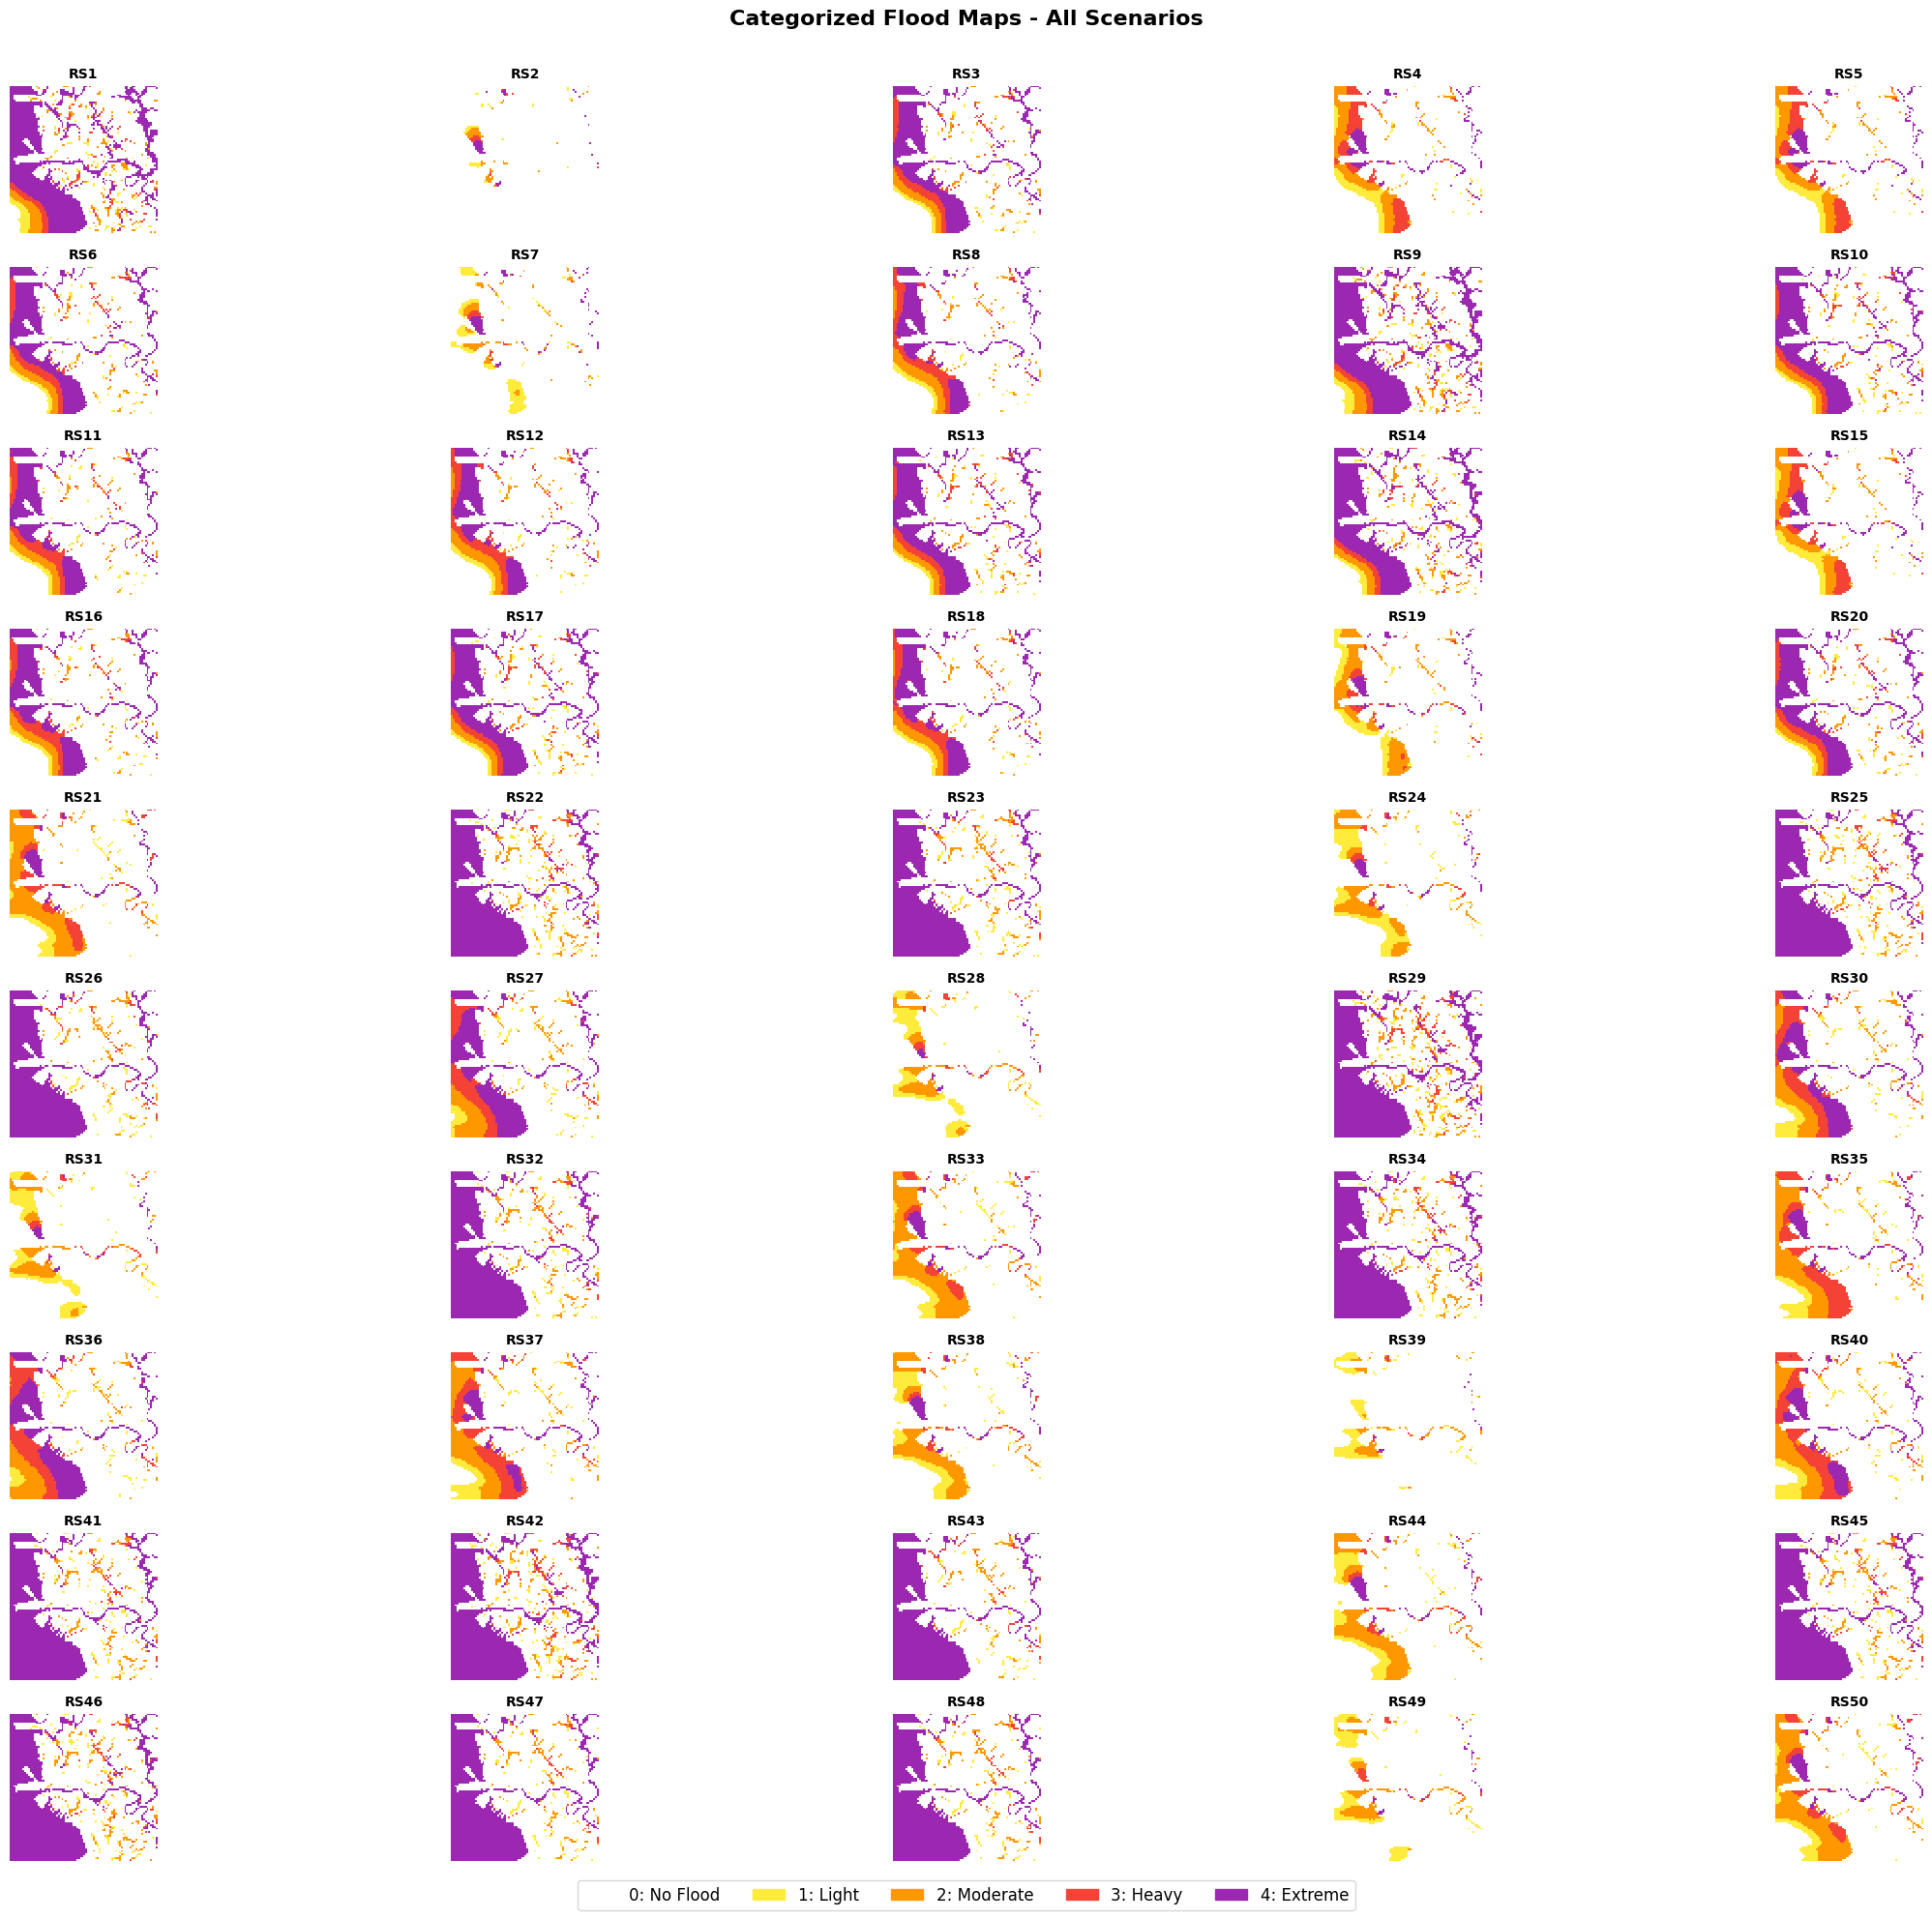

In [23]:
reconstructed_maps = []
for patch_labels, metadata in zip(flood_maps_categorized_patch, patch_metadata):
    reconstructed = reconstruct_map_from_patches(patch_labels, metadata, method='nearest')
    reconstructed_maps.append(reconstructed)

fig_all = visualize_all_categorized_maps(reconstructed_maps, scenario_ids=list(range(1, 51)), figsize=(25, 20), ncols=5)
plt.show()

In [24]:
display(flood_maps_categorized_patch)
# display(patch_metadata)

[array([4, 4, 4, ..., 0, 2, 0], shape=(6400,), dtype=int8),
 array([0, 0, 0, ..., 0, 0, 0], shape=(6400,), dtype=int8),
 array([4, 4, 4, ..., 0, 0, 0], shape=(6400,), dtype=int8),
 array([2, 2, 2, ..., 0, 0, 0], shape=(6400,), dtype=int8),
 array([2, 2, 2, ..., 0, 0, 0], shape=(6400,), dtype=int8),
 array([4, 4, 4, ..., 0, 0, 0], shape=(6400,), dtype=int8),
 array([0, 0, 0, ..., 0, 0, 0], shape=(6400,), dtype=int8),
 array([3, 3, 4, ..., 0, 0, 0], shape=(6400,), dtype=int8),
 array([4, 4, 4, ..., 0, 2, 0], shape=(6400,), dtype=int8),
 array([4, 4, 4, ..., 0, 1, 0], shape=(6400,), dtype=int8),
 array([4, 4, 4, ..., 0, 0, 0], shape=(6400,), dtype=int8),
 array([3, 4, 4, ..., 0, 0, 0], shape=(6400,), dtype=int8),
 array([4, 4, 4, ..., 0, 0, 0], shape=(6400,), dtype=int8),
 array([4, 4, 4, ..., 0, 0, 0], shape=(6400,), dtype=int8),
 array([2, 2, 2, ..., 0, 0, 0], shape=(6400,), dtype=int8),
 array([4, 4, 4, ..., 0, 0, 0], shape=(6400,), dtype=int8),
 array([4, 4, 4, ..., 0, 0, 0], shape=(6

# Data Splitting Strategy

In [25]:
print(train_rainfall_scenarios)

[        hour  intensity_mmhr
0   0.000000        3.031412
1   0.083333       13.742447
2   0.166667       25.447122
3   0.250000       35.675799
4   0.333333       43.107607
5   0.416667       46.995613
6   0.500000       46.995613
7   0.583333       43.107607
8   0.666667       35.675799
9   0.750000       25.447122
10  0.833333       13.742447
11  0.916667        3.031412
12  1.000000        0.000000,         hour  intensity_mmhr
0   0.000000        5.738031
1   0.083333       26.012490
2   0.166667       48.167766
3   0.250000       67.529190
4   0.333333       81.596542
5   0.416667       88.955981
6   0.500000       88.955981
7   0.583333       81.596542
8   0.666667       67.529190
9   0.750000       48.167766
10  0.833333       26.012490
11  0.916667        5.738031
12  1.000000        0.000000,         hour  intensity_mmhr
0   0.000000        8.444649
1   0.083333       38.282532
2   0.166667       70.888411
3   0.250000       99.382582
4   0.333333      120.085476
5   0.41666

In [26]:
print("\nScenario Split")
print("-" * 70)

import os
import re

def get_scenario_ids_from_dir(folder_path: str) -> List[int]:
    ids = []
    for fname in os.listdir(folder_path):
        if not os.path.isfile(os.path.join(folder_path, fname)):
            continue
        match = re.search(r'Scenario_(\d+)_mmhr', fname)
        if match:
            ids.append(int(match.group(1)))
    return sorted(ids)

train_scenario_ids = get_scenario_ids_from_dir(train_rs_path)
test_scenario_ids  = get_scenario_ids_from_dir(test_rs_path)

NUM_TRAIN = len(train_scenario_ids)
NUM_TEST  = len(test_scenario_ids)

print(f"Total scenarios: {NUM_TRAIN + NUM_TEST}")
print(f"Training scenarios: {NUM_TRAIN}")
print(f"Test scenarios: {NUM_TEST}")

train_rs_lookup = {sid: df for sid, df in zip(train_scenario_ids, train_rainfall_scenarios)}
test_rs_lookup  = {sid: df for sid, df in zip(test_scenario_ids,  test_rainfall_scenarios)}


def extract_rainfall_sequence(rainfall_df) -> np.ndarray:
    if 'intensity_mmhr' in rainfall_df.columns:
        return rainfall_df['intensity_mmhr'].values.astype(np.float32)
    
print("\nTraining Set Organization")
print("-" * 70)

train_data = {
    'scenario_ids':       train_scenario_ids,
    'num_scenarios':      NUM_TRAIN,
    'dem':                dem_normalized,
    'infiltration':       infilt_normalized,
    'landuse':            landuse_normalized,
    'rainfall_sequences': [],   # List of (13,) arrays
    'flood_patches':      [],   # List of (6400,) label arrays
}

for scenario_id in train_scenario_ids:
    flood_idx = scenario_id - 1  # flood_maps_categorized_patch is 0-indexed by scenario number

    seq = extract_rainfall_sequence(train_rs_lookup[scenario_id])  # (13,)
    train_data['rainfall_sequences'].append(seq)
    train_data['flood_patches'].append(flood_maps_categorized_patch[flood_idx])

print(f"Training Set:")
print(f"  Scenario IDs:      {train_data['scenario_ids']}")
print(f"  Number of scenarios: {train_data['num_scenarios']}")
print(f"  Rainfall sequences: {len(train_data['rainfall_sequences'])} × shape {train_data['rainfall_sequences'][0].shape}")
print(f"  Flood patches:      {len(train_data['flood_patches'])} arrays")
print(f"  Patches per scenario: {len(train_data['flood_patches'][0])}")
print(f"  Total training patches: {len(train_data['flood_patches'][0]) * train_data['num_scenarios']:,}")

print("\nTest Set Organization")
print("-" * 70)

test_data = {
    'scenario_ids':       test_scenario_ids,
    'num_scenarios':      NUM_TEST,
    'dem':                dem_normalized,
    'infiltration':       infilt_normalized,
    'landuse':            landuse_normalized,
    'rainfall_sequences': [],   # List of (13,) arrays
    'flood_patches':      [],   # List of (6400,) label arrays
}

for scenario_id in test_scenario_ids:
    flood_idx = scenario_id - 1
    seq = extract_rainfall_sequence(test_rs_lookup[scenario_id])  # (13,)
    test_data['rainfall_sequences'].append(seq)
    test_data['flood_patches'].append(flood_maps_categorized_patch[flood_idx])

print(f"Test Set:")
print(f"  Scenario IDs:      {test_data['scenario_ids']}")
print(f"  Number of scenarios: {test_data['num_scenarios']}")
print(f"  Rainfall sequences: {len(test_data['rainfall_sequences'])} × shape {test_data['rainfall_sequences'][0].shape}")
print(f"  Flood patches:      {len(test_data['flood_patches'])} arrays")
print(f"  Patches per scenario: {len(test_data['flood_patches'][0])}")
print(f"  Total test patches: {len(test_data['flood_patches'][0]) * test_data['num_scenarios']:,}")


Scenario Split
----------------------------------------------------------------------
Total scenarios: 50
Training scenarios: 35
Test scenarios: 15

Training Set Organization
----------------------------------------------------------------------
Training Set:
  Scenario IDs:      [2, 3, 5, 6, 7, 8, 9, 12, 13, 14, 15, 16, 18, 19, 21, 22, 23, 25, 26, 28, 30, 31, 32, 33, 34, 36, 38, 40, 42, 45, 46, 47, 48, 49, 50]
  Number of scenarios: 35
  Rainfall sequences: 35 × shape (13,)
  Flood patches:      35 arrays
  Patches per scenario: 6400
  Total training patches: 224,000

Test Set Organization
----------------------------------------------------------------------
Test Set:
  Scenario IDs:      [1, 4, 10, 11, 17, 20, 24, 27, 29, 35, 37, 39, 41, 43, 44]
  Number of scenarios: 15
  Rainfall sequences: 15 × shape (13,)
  Flood patches:      15 arrays
  Patches per scenario: 6400
  Total test patches: 96,000


# Patch Extraction for ViT

In [27]:
print("\nPatch Extraction Strategy")
print("-" * 70)
print("Strategy: Non-overlapping patches")

num_patches_h = 320 // PATCH_SIZE
num_patches_w = 320 // PATCH_SIZE
total_patches = num_patches_h * num_patches_w

def extract_patches_2d(image: np.ndarray, patch_size: int) -> np.ndarray:
    h, w = image.shape
    assert h % patch_size == 0 and w % patch_size == 0, "Image size must be divisible by patch_size"
    
    num_patches_h = h // patch_size
    num_patches_w = w // patch_size
    
    # Reshape to extract patches
    patches = image.reshape(num_patches_h, patch_size, num_patches_w, patch_size)
    patches = patches.transpose(0, 2, 1, 3)  # (num_h, num_w, patch_size, patch_size)
    patches = patches.reshape(-1, patch_size, patch_size)  # (num_patches, patch_size, patch_size)
    
    return patches


Patch Extraction Strategy
----------------------------------------------------------------------
Strategy: Non-overlapping patches


In [28]:
print("\nStacking Spatial Inputs")
print("-" * 70)

def extract_spatial_patches(dem: np.ndarray, infiltration: np.ndarray, landuse: np.ndarray, patch_size: int) -> np.ndarray:
    # Extract patches from each layer
    dem_patches = extract_patches_2d(dem, patch_size)
    infilt_patches = extract_patches_2d(infiltration, patch_size)
    landuse_patches = extract_patches_2d(landuse, patch_size)
    
    # Stack as channels (num_patches, 3, patch_size, patch_size)
    stacked_patches = np.stack([dem_patches, infilt_patches, landuse_patches], axis=1)
    return stacked_patches

# Extract spatial patches (these are shared across all scenarios)
spatial_patches = extract_spatial_patches(dem_normalized, infilt_normalized, landuse_normalized, PATCH_SIZE)
print(f"Spatial patches extracted:")
print(f"  Shape: {spatial_patches.shape}")
print(f"  Expected: ({total_patches}, 3, {PATCH_SIZE}, {PATCH_SIZE})")


Stacking Spatial Inputs
----------------------------------------------------------------------
Spatial patches extracted:
  Shape: (6400, 3, 4, 4)
  Expected: (6400, 3, 4, 4)


In [29]:
print("\nCreating Complete Dataset Structure")
print("-" * 70)

def create_patch_dataset(spatial_patches, scenario_ids, rainfall_sequences, patch_labels):
    num_scenarios       = len(scenario_ids)
    patches_per_scenario = spatial_patches.shape[0]
    total_samples       = num_scenarios * patches_per_scenario

    rain_array = np.stack(rainfall_sequences, axis=0)  # (num_scenarios, 13)

    dataset = {
        'spatial_patches':    np.tile(spatial_patches[np.newaxis], (num_scenarios, 1, 1, 1, 1)),
        'rainfall_sequences': np.tile(rain_array[:, np.newaxis, :], (1, patches_per_scenario, 1)),
        'labels':             np.stack(patch_labels, axis=0),
        'scenario_ids':       scenario_ids,
        'num_scenarios':      num_scenarios,
        'patches_per_scenario': patches_per_scenario,
        'total_samples':      total_samples,
    }
    return dataset

print("\nCreating training dataset...")
train_dataset = create_patch_dataset(
    spatial_patches,
    train_scenario_ids,
    train_data['rainfall_sequences'], 
    train_data['flood_patches']
)

print(f"Training dataset:")
print(f"  Spatial patches:    {train_dataset['spatial_patches'].shape}")
print(f"  Rainfall sequences: {train_dataset['rainfall_sequences'].shape}")
print(f"  Labels:             {train_dataset['labels'].shape}")
print(f"  Total samples:      {train_dataset['total_samples']:,}")

print("\nCreating test dataset...")
test_dataset = create_patch_dataset(
    spatial_patches,
    test_scenario_ids,
    test_data['rainfall_sequences'],  
    test_data['flood_patches']
)

print(f"Test dataset:")
print(f"  Spatial patches:    {test_dataset['spatial_patches'].shape}")
print(f"  Rainfall sequences: {test_dataset['rainfall_sequences'].shape}")
print(f"  Labels:             {test_dataset['labels'].shape}")
print(f"  Total samples:      {test_dataset['total_samples']:,}")


Creating Complete Dataset Structure
----------------------------------------------------------------------

Creating training dataset...
Training dataset:
  Spatial patches:    (35, 6400, 3, 4, 4)
  Rainfall sequences: (35, 6400, 13)
  Labels:             (35, 6400)
  Total samples:      224,000

Creating test dataset...
Test dataset:
  Spatial patches:    (15, 6400, 3, 4, 4)
  Rainfall sequences: (15, 6400, 13)
  Labels:             (15, 6400)
  Total samples:      96,000


In [30]:
print("\n" + "="*70)
print("DATALOADER SETUP (with Temporal Sequences)")
print("="*70)

print("\nCreating PyTorch Dataset Class")
print("-" * 70)

class FloodPatchDataset(Dataset):
    def __init__(self, dataset_dict: Dict, transform=None):
        self.spatial_patches = dataset_dict['spatial_patches']      
        self.rainfall_sequences = dataset_dict['rainfall_sequences']
        self.labels = dataset_dict['labels']                         
        
        self.num_scenarios = dataset_dict['num_scenarios']
        self.patches_per_scenario = dataset_dict['patches_per_scenario']
        self.total_samples = dataset_dict['total_samples']
        self.scenario_ids = dataset_dict['scenario_ids']
        
        self.transform = transform
        
        # Flatten arrays for easier indexing
        # Spatial: (total_samples, 3, H, W)
        self.spatial_patches_flat = self.spatial_patches.reshape(
            self.total_samples, *self.spatial_patches.shape[2:]
        )
        
        # Rainfall sequences: (total_samples, 13)
        self.rainfall_sequences_flat = self.rainfall_sequences.reshape(
            self.total_samples, -1
        )
        
        # Labels: (total_samples,)
        self.labels_flat = self.labels.flatten()
        
        print(f"FloodPatchDataset initialized:")
        print(f"  Total samples: {self.total_samples:,}")
        print(f"  Scenarios: {self.num_scenarios}")
        print(f"  Patches per scenario: {self.patches_per_scenario}")
        print(f"  Spatial patch shape: {self.spatial_patches_flat.shape[1:]}")
        print(f"  Rainfall sequence shape: {self.rainfall_sequences_flat.shape[1:]}")
        
    def __len__(self) -> int:
        return self.total_samples
    
    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        # Get spatial patch (3, H, W)
        spatial_patch = self.spatial_patches_flat[idx]
        
        # Get rainfall sequence (13,)
        rainfall_seq = self.rainfall_sequences_flat[idx]
        
        # Get label (scalar)
        label = self.labels_flat[idx]
        
        # Convert to PyTorch tensors
        spatial_patch = torch.from_numpy(spatial_patch).float()
        rainfall_seq = torch.from_numpy(rainfall_seq).float() 
        label = torch.tensor(label, dtype=torch.long)
        
        # Apply transform
        if self.transform:
            spatial_patch = self.transform(spatial_patch)
        
        return spatial_patch, rainfall_seq, label
    
    def get_scenario_id(self, idx: int) -> int:
        scenario_idx = idx // self.patches_per_scenario
        return self.scenario_ids[scenario_idx]


# Create PyTorch datasets
train_pytorch_dataset = FloodPatchDataset(train_dataset)
test_pytorch_dataset = FloodPatchDataset(test_dataset)

print(f"\n PyTorch datasets created:")
print(f"  Training: {len(train_pytorch_dataset):,} samples")
print(f"  Test: {len(test_pytorch_dataset):,} samples")

# Test dataset
print("\nEvaluate Dataset")
print("-" * 70)
sample_spatial, sample_rainfall, sample_label = train_pytorch_dataset[0]
print(f"Sample 0:")
print(f"  Spatial patch shape: {sample_spatial.shape}")
print(f"  Rainfall sequence shape: {sample_rainfall.shape}") 
print(f"  Rainfall sequence: {sample_rainfall}")
print(f"  Label: {sample_label.item()} ({FLOOD_CLASSES[sample_label.item()]['name']})")
print(f"  Scenario ID: {train_pytorch_dataset.get_scenario_id(0)}")


DATALOADER SETUP (with Temporal Sequences)

Creating PyTorch Dataset Class
----------------------------------------------------------------------
FloodPatchDataset initialized:
  Total samples: 224,000
  Scenarios: 35
  Patches per scenario: 6400
  Spatial patch shape: (3, 4, 4)
  Rainfall sequence shape: (13,)
FloodPatchDataset initialized:
  Total samples: 96,000
  Scenarios: 15
  Patches per scenario: 6400
  Spatial patch shape: (3, 4, 4)
  Rainfall sequence shape: (13,)

 PyTorch datasets created:
  Training: 224,000 samples
  Test: 96,000 samples

Evaluate Dataset
----------------------------------------------------------------------
Sample 0:
  Spatial patch shape: torch.Size([3, 4, 4])
  Rainfall sequence shape: torch.Size([13])
  Rainfall sequence: tensor([ 3.0314, 13.7424, 25.4471, 35.6758, 43.1076, 46.9956, 46.9956, 43.1076,
        35.6758, 25.4471, 13.7424,  3.0314,  0.0000])
  Label: 0 (No Flood)
  Scenario ID: 2


# ViT Architecture

In [ ]:
print("\n" + "="*70)
print("VIT ARCHITECTURE DESIGN (WITH TEMPORAL RAINFALL)")
print("="*70)

# Model hyperparameters
IN_CHANNELS = 3       
PATCH_SIZE = 4       
NUM_CLASSES = 5      
NUM_TIMESTEPS = 13   

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Compare all available configurations
compare_all_configurations()

print("\n" + "="*70)
print("CREATING MODEL")
print("="*70)

model = create_small_regularized_model()
model = model.to(device)

# Print summary
print(get_model_summary(model))

# Print detailed architecture
print_model_details(model)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


VIT ARCHITECTURE DESIGN (WITH TEMPORAL RAINFALL)
Device: cpu

MODEL CONFIGURATION COMPARISON (WITH TEMPORAL RAINFALL)
Dataset: 96,000 training samples
Patch size: 4x4
Input channels: 3 (DEM, Infiltration, Landuse)
Rainfall timesteps: 13 (temporal sequence)
Output classes: 5

Config                         Params       Embed    Layers   Heads    Rain Method  Dropout   
------------------------------------------------------------------------------------------
Tiny ViT (Temporal)               883,333  128      4        4        conv         0.10      
Compact ViT (Temporal)          2,791,941  192      6        6        conv         0.10      
Small ViT (Temporal)            4,902,021  256      6        8        conv         0.10      
Small ViT (Reg, Temp)           4,902,021  256      6        8        conv         0.25      
Medium ViT (Temporal)          14,465,157  384      8        8        conv         0.15      
Base ViT (Temporal)            38,236,805  512      12       8     

In [32]:
print(model)

ViTFloodClassifier(
  (patch_embedding): PatchEmbedding(
    (projection): Conv2d(3, 256, kernel_size=(4, 4), stride=(4, 4))
  )
  (rainfall_embedding): RainfallSequenceEmbedding(
    (temporal_encoder): Sequential(
      (0): Conv1d(1, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): GELU(approximate='none')
      (2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (3): GELU(approximate='none')
      (4): AdaptiveAvgPool1d(output_size=1)
      (5): Flatten(start_dim=1, end_dim=-1)
    )
    (projection): Linear(in_features=128, out_features=256, bias=True)
  )
  (pos_encoding): PositionalEncoding()
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerBlock(
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_feat

# Training Setup

In [33]:
patches_per_scenario = 6400
scenario_to_samples = {}
for idx, scenario_id in enumerate(train_scenario_ids):
    start = idx * patches_per_scenario
    end = start + patches_per_scenario
    scenario_to_samples[scenario_id] = list(range(start, end))

fold_histories, best_fold = train_kfold(
    model_factory=create_small_model,
    full_dataset=train_pytorch_dataset,
    scenario_to_samples=scenario_to_samples,
    batch_size=32,
    num_epochs=10,
    device=device,
    num_folds = 3
)


K-FOLD CROSS-VALIDATION

Fold 1: Train=24 scenarios, Val=11
  Train: [2, 3, 5, 6, 7, 8, 9, 12, 15, 16, 21, 25, 26, 30, 32, 33, 36, 40, 42, 46, 47, 48, 49, 50]
  Val: [13, 14, 18, 19, 22, 23, 28, 31, 34, 38, 45]

Fold 2: Train=24 scenarios, Val=11
  Train: [9, 12, 13, 14, 15, 18, 19, 21, 22, 23, 26, 28, 30, 31, 32, 33, 34, 36, 38, 42, 45, 46, 47, 50]
  Val: [2, 3, 5, 6, 7, 8, 16, 25, 40, 48, 49]

Fold 3: Train=22 scenarios, Val=13
  Train: [2, 3, 5, 6, 7, 8, 13, 14, 16, 18, 19, 22, 23, 25, 28, 31, 34, 38, 40, 45, 48, 49]
  Val: [9, 12, 15, 21, 26, 30, 32, 33, 36, 42, 46, 47, 50]

Fold 1: 153,600 train, 70,400 val

FOLD 1/3

Class distribution:
  Class 0: 110,417 (71.89%) weight=0.278
  Class 1:  4,380 ( 2.85%) weight=7.014
  Class 2:  8,878 ( 5.78%) weight=3.460
  Class 3:  5,788 ( 3.77%) weight=5.308
  Class 4: 24,137 (15.71%) weight=1.273
Epoch   1/10 | LR:0.000000 | Train Loss:1.5269 Acc:0.1411 | Val Loss:1.5301 Acc:0.1731
  → Best!
Epoch   2/10 | LR:0.000010 | Train Loss:1.3248 Acc

# Testing

In [34]:
print("\n" + "="*70)
print("TEST EVALUATION")
print("="*70)

print("\nLoading best model from training...")
best_fold_idx = best_fold  

model = create_small_model()
model_path = f'./checkpoints/fold_{best_fold_idx + 1}/best_model.pt'
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

print(f"✓ Loaded model from Fold {best_fold_idx + 1}")
print(f"  Model path: {model_path}")


TEST EVALUATION

Loading best model from training...
✓ Loaded model from Fold 3
  Model path: ./checkpoints/fold_3/best_model.pt


In [35]:
print("\nPreparing ground truth maps for test scenarios...")
ground_truth_maps = {}

for scenario_id in test_scenario_ids:
    # Get the index in test_dataset arrays
    scenario_idx = test_scenario_ids.index(scenario_id)
    # Extract ground truth from test_dataset
    ground_truth_patches = test_dataset['labels'][scenario_idx] 
    # Reconstruct to 320×320 map
    ground_truth_map = reconstruct_test_map_from_patches(ground_truth_patches)
    ground_truth_maps[scenario_id] = ground_truth_map
    print(f"  Scenario {scenario_id}: Ground truth shape {ground_truth_map.shape}")
print(f"✓ Prepared {len(ground_truth_maps)} ground truth maps")



Preparing ground truth maps for test scenarios...
  Scenario 1: Ground truth shape (320, 320)
  Scenario 4: Ground truth shape (320, 320)
  Scenario 10: Ground truth shape (320, 320)
  Scenario 11: Ground truth shape (320, 320)
  Scenario 17: Ground truth shape (320, 320)
  Scenario 20: Ground truth shape (320, 320)
  Scenario 24: Ground truth shape (320, 320)
  Scenario 27: Ground truth shape (320, 320)
  Scenario 29: Ground truth shape (320, 320)
  Scenario 35: Ground truth shape (320, 320)
  Scenario 37: Ground truth shape (320, 320)
  Scenario 39: Ground truth shape (320, 320)
  Scenario 41: Ground truth shape (320, 320)
  Scenario 43: Ground truth shape (320, 320)
  Scenario 44: Ground truth shape (320, 320)
✓ Prepared 15 ground truth maps



Evaluating all test scenarios...

EVALUATING TEST SCENARIOS

[Scenario 1] Predicting...
[Scenario 1] Results:
  Accuracy:  0.5841
  Mean IoU:  0.1701
  IoU per class:
    Class 0: 0.7852
    Class 1: 0.0541
    Class 2: 0.0112
    Class 3: 0.0000
    Class 4: 0.0000

[Scenario 4] Predicting...
[Scenario 4] Results:
  Accuracy:  0.7252
  Mean IoU:  0.1983
  IoU per class:
    Class 0: 0.8540
    Class 1: 0.1263
    Class 2: 0.0114
    Class 3: 0.0000
    Class 4: 0.0000

[Scenario 10] Predicting...
[Scenario 10] Results:
  Accuracy:  0.7942
  Mean IoU:  0.2705
  IoU per class:
    Class 0: 0.8149
    Class 1: 0.0000
    Class 2: 0.0337
    Class 3: 0.0000
    Class 4: 0.5041

[Scenario 11] Predicting...
[Scenario 11] Results:
  Accuracy:  0.6666
  Mean IoU:  0.1805
  IoU per class:
    Class 0: 0.8423
    Class 1: 0.0473
    Class 2: 0.0128
    Class 3: 0.0000
    Class 4: 0.0000

[Scenario 17] Predicting...
[Scenario 17] Results:
  Accuracy:  0.7823
  Mean IoU:  0.2677
  IoU per class

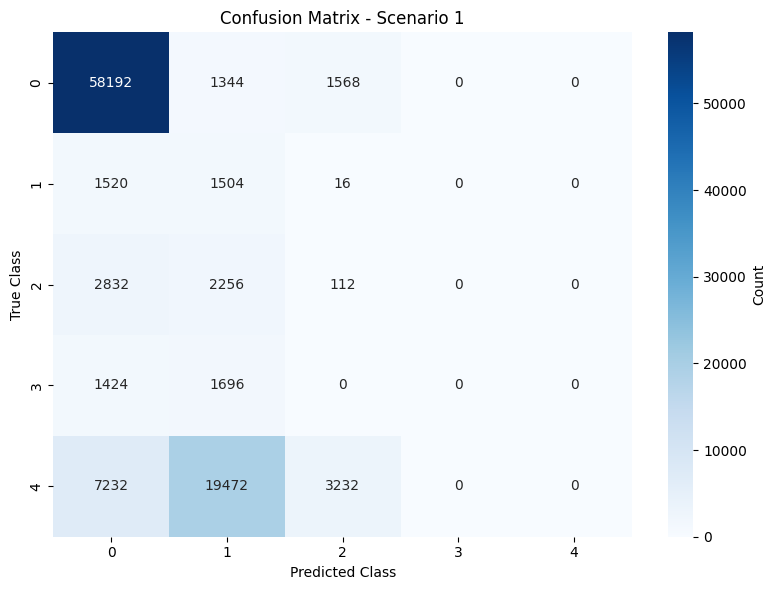

Comparison plot saved to results\comparison_scenario_1.png


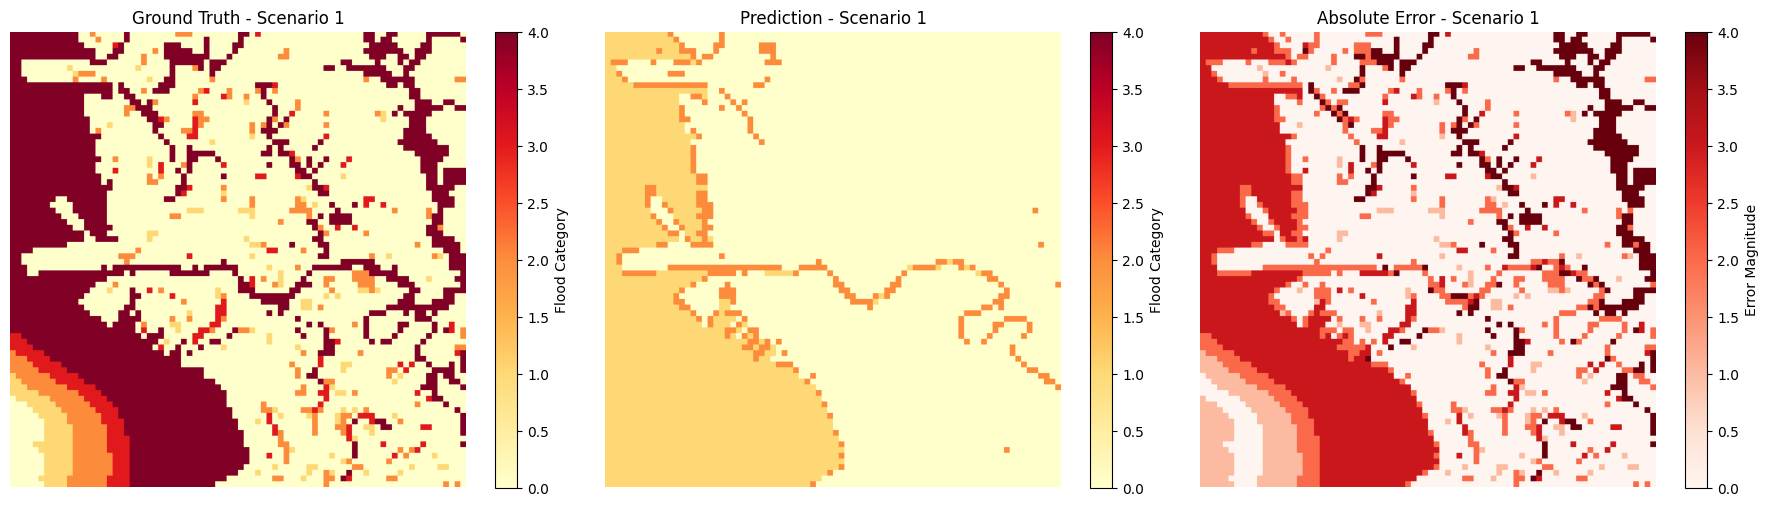


Visualizing Scenario 4...
Confusion matrix saved to results\confusion_matrix_scenario_4.png


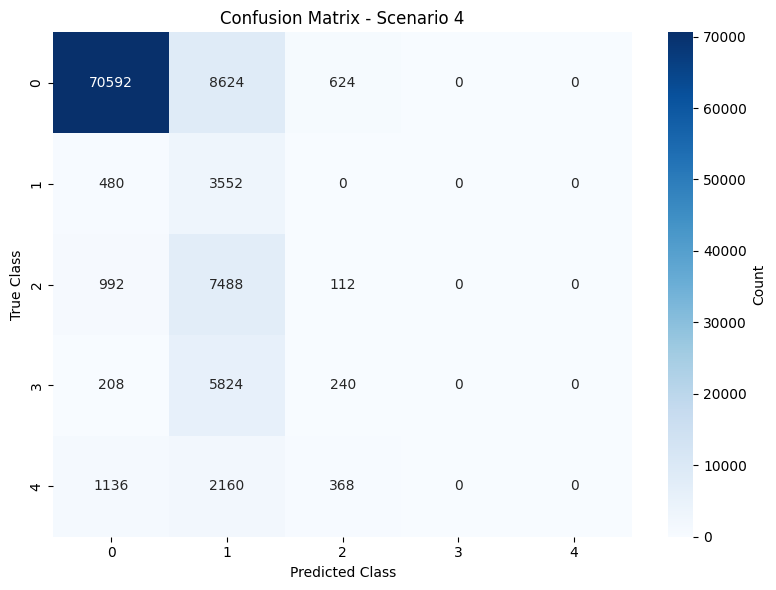

Comparison plot saved to results\comparison_scenario_4.png


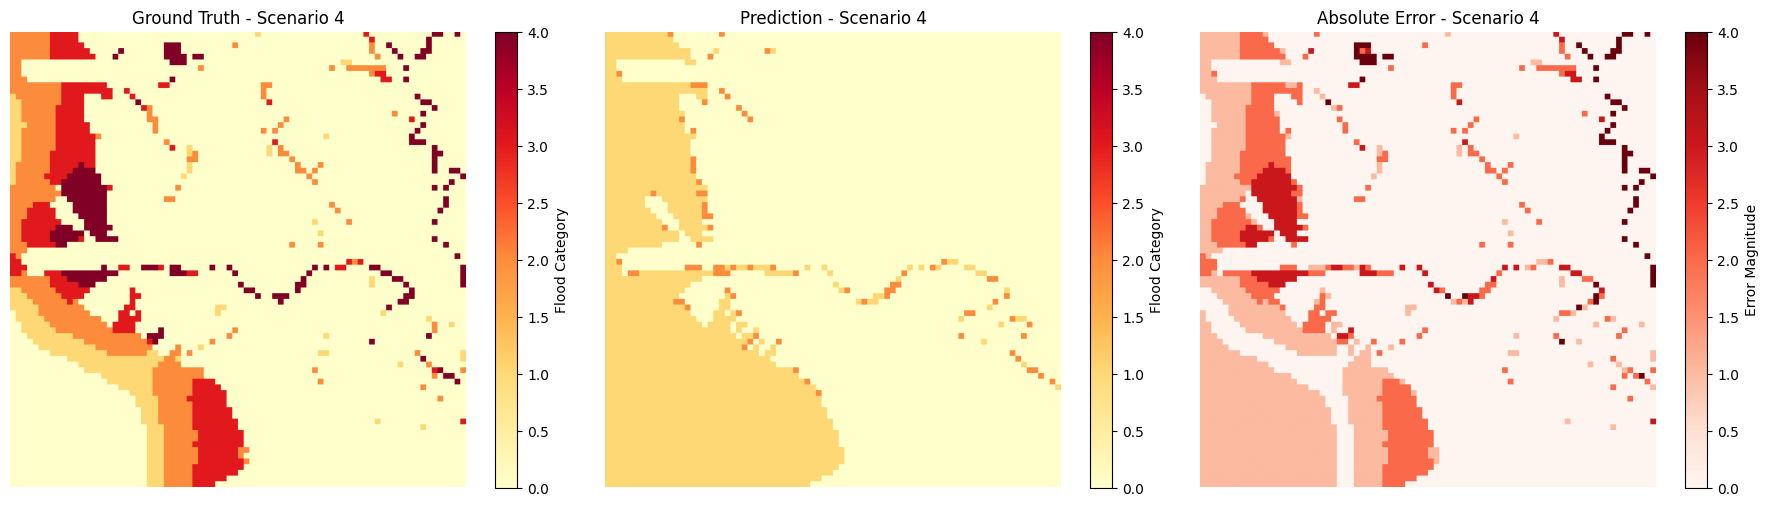


Visualizing Scenario 10...
Confusion matrix saved to results\confusion_matrix_scenario_10.png


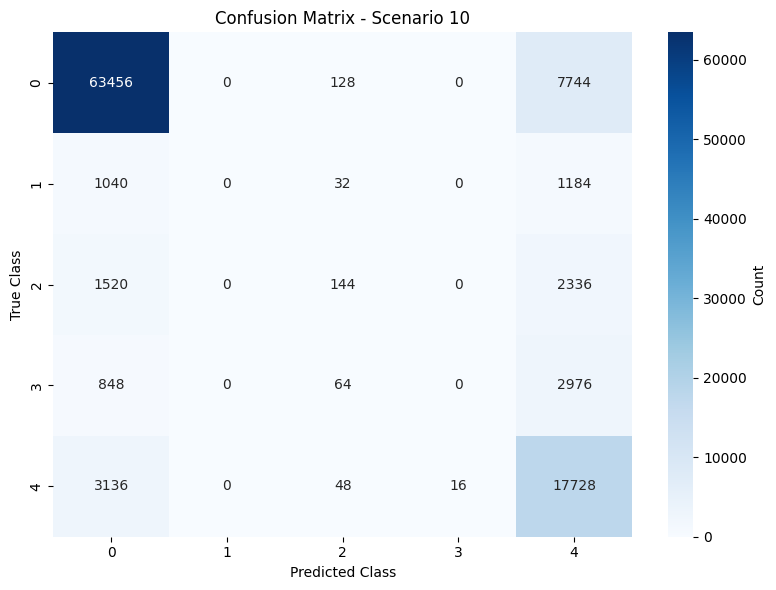

Comparison plot saved to results\comparison_scenario_10.png


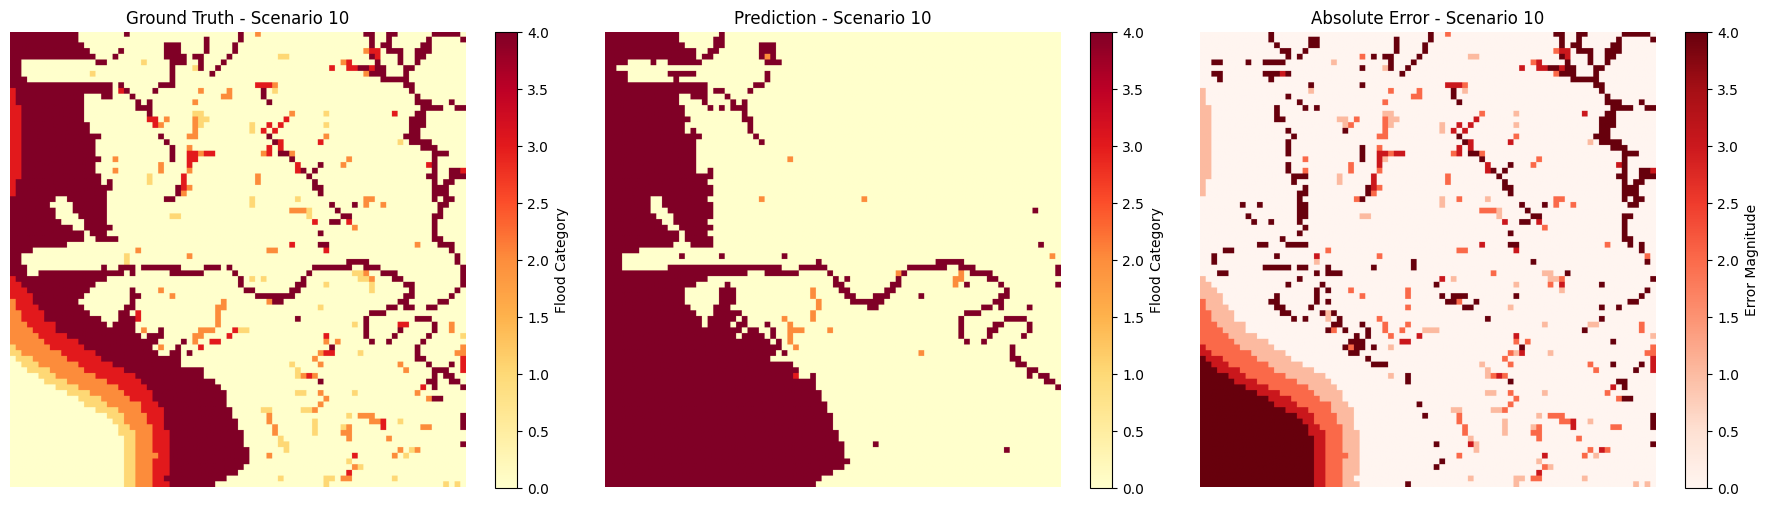


Visualizing Scenario 11...
Confusion matrix saved to results\confusion_matrix_scenario_11.png


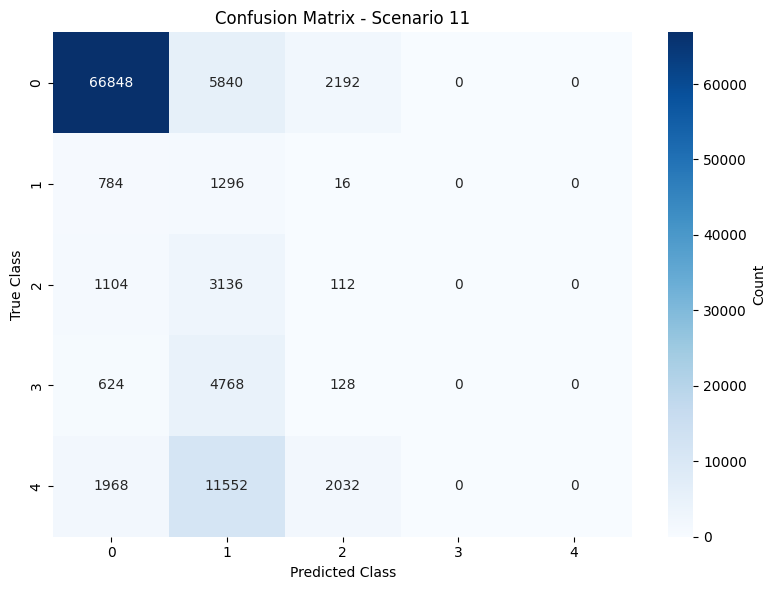

Comparison plot saved to results\comparison_scenario_11.png


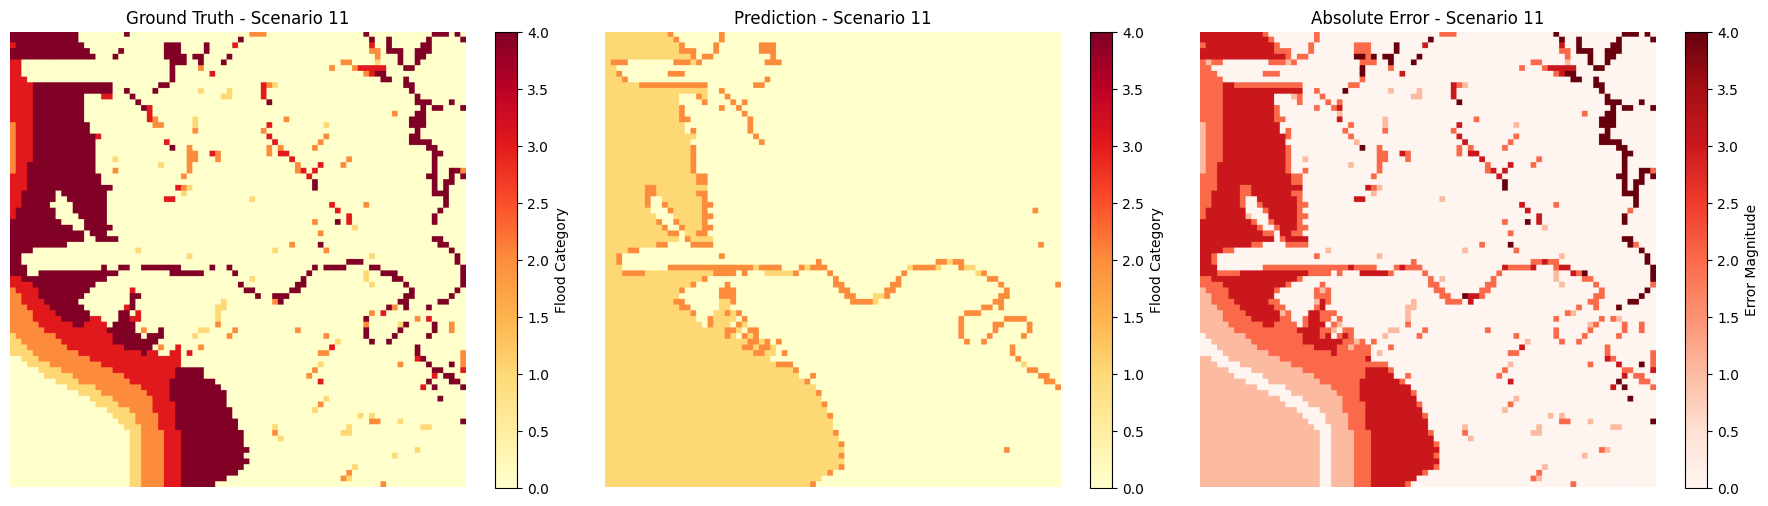


Visualizing Scenario 17...
Confusion matrix saved to results\confusion_matrix_scenario_17.png


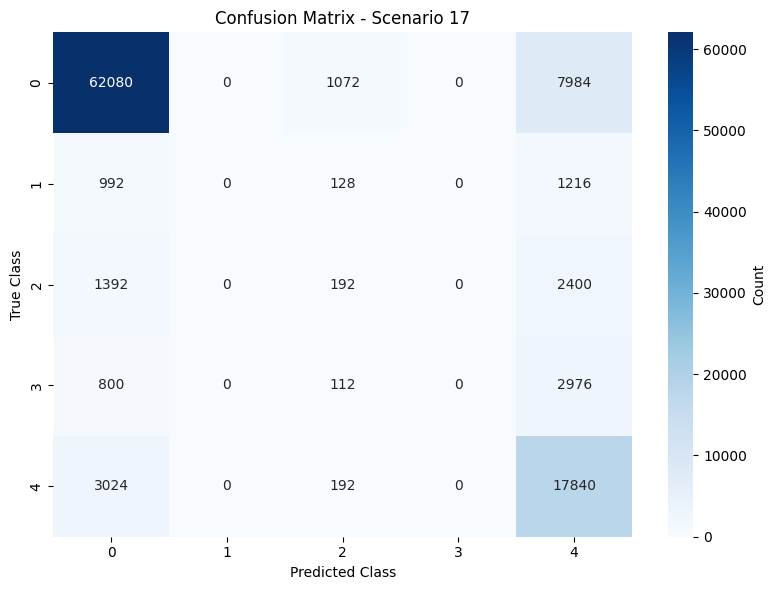

Comparison plot saved to results\comparison_scenario_17.png


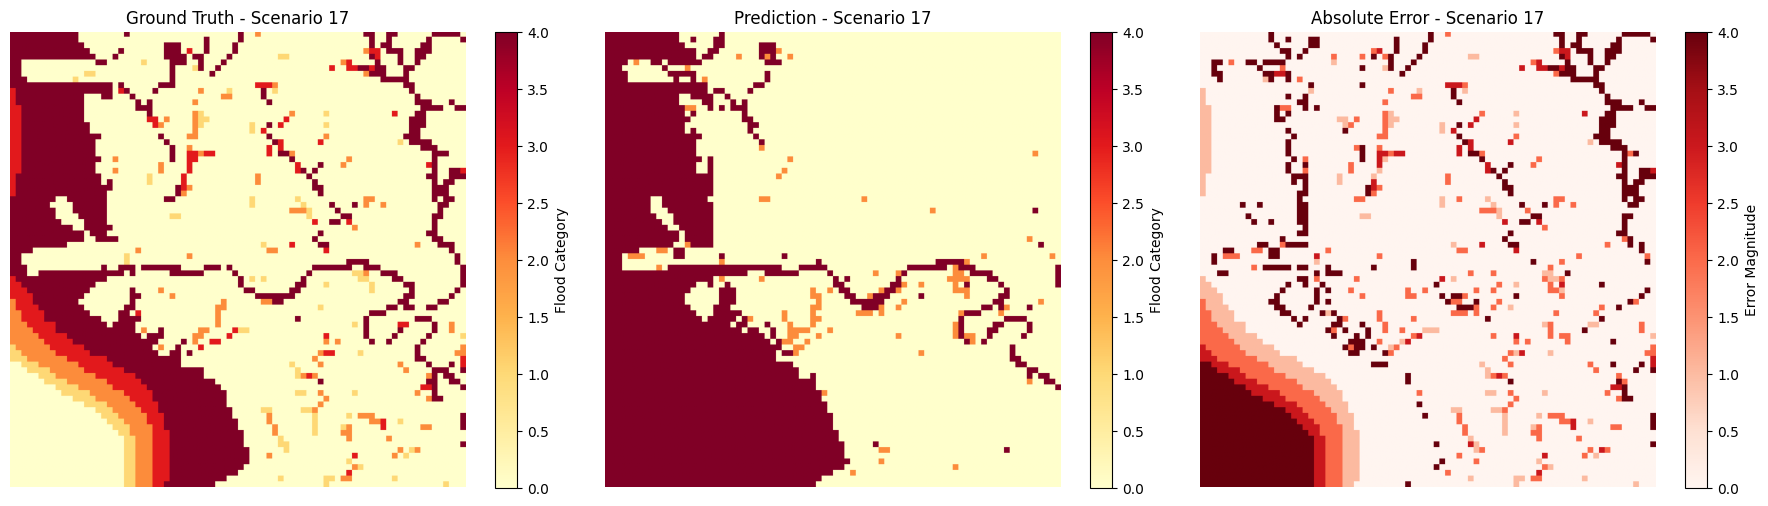


Visualizing Scenario 20...
Confusion matrix saved to results\confusion_matrix_scenario_20.png


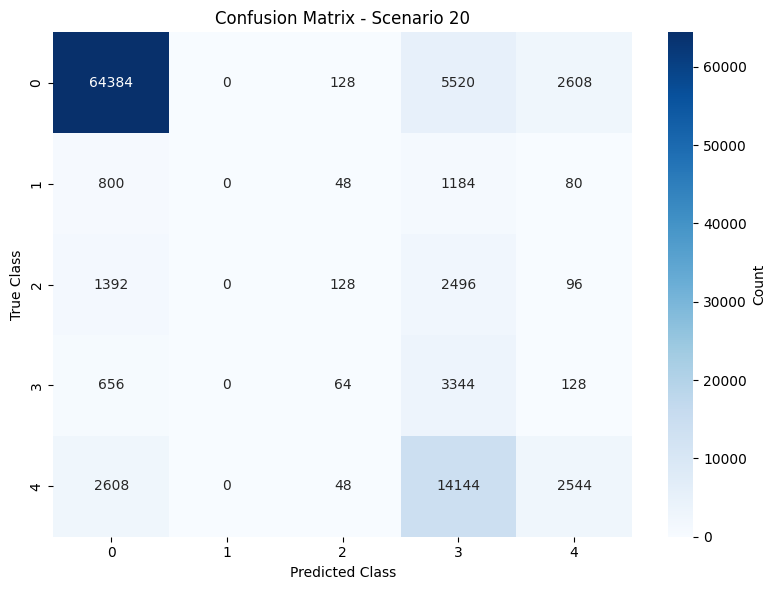

Comparison plot saved to results\comparison_scenario_20.png


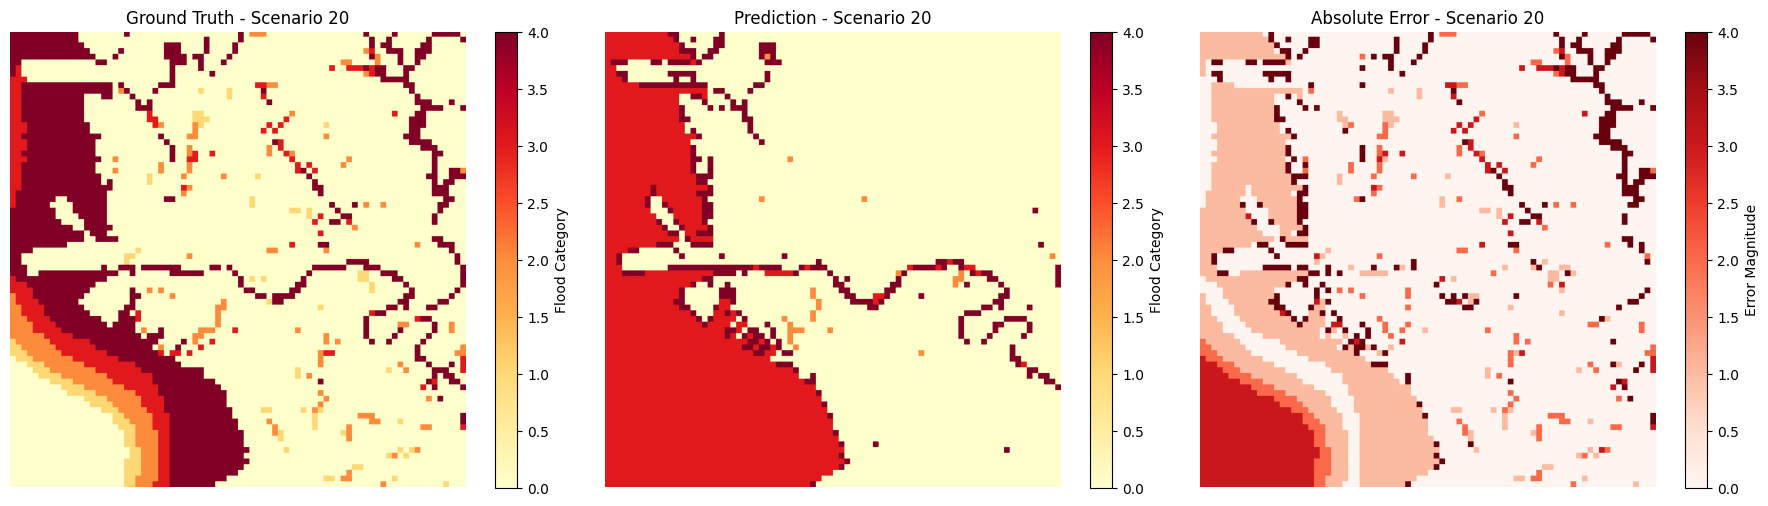


Visualizing Scenario 24...
Confusion matrix saved to results\confusion_matrix_scenario_24.png


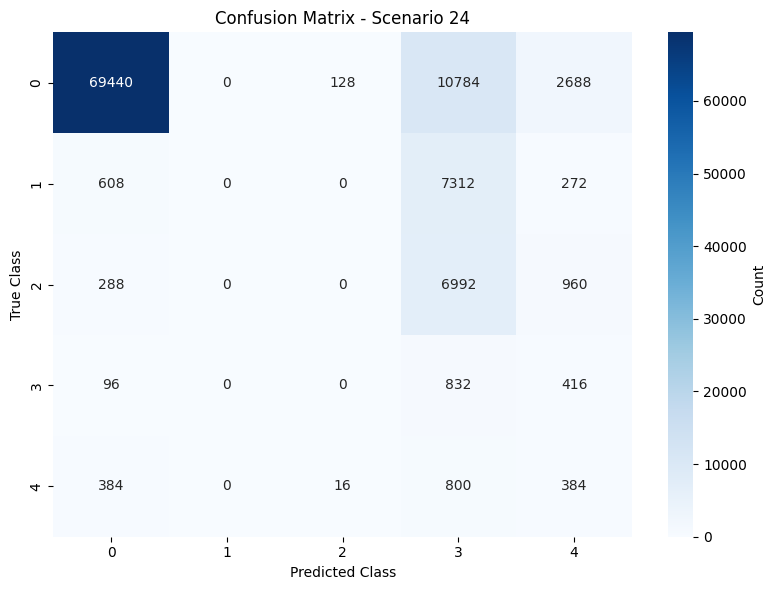

Comparison plot saved to results\comparison_scenario_24.png


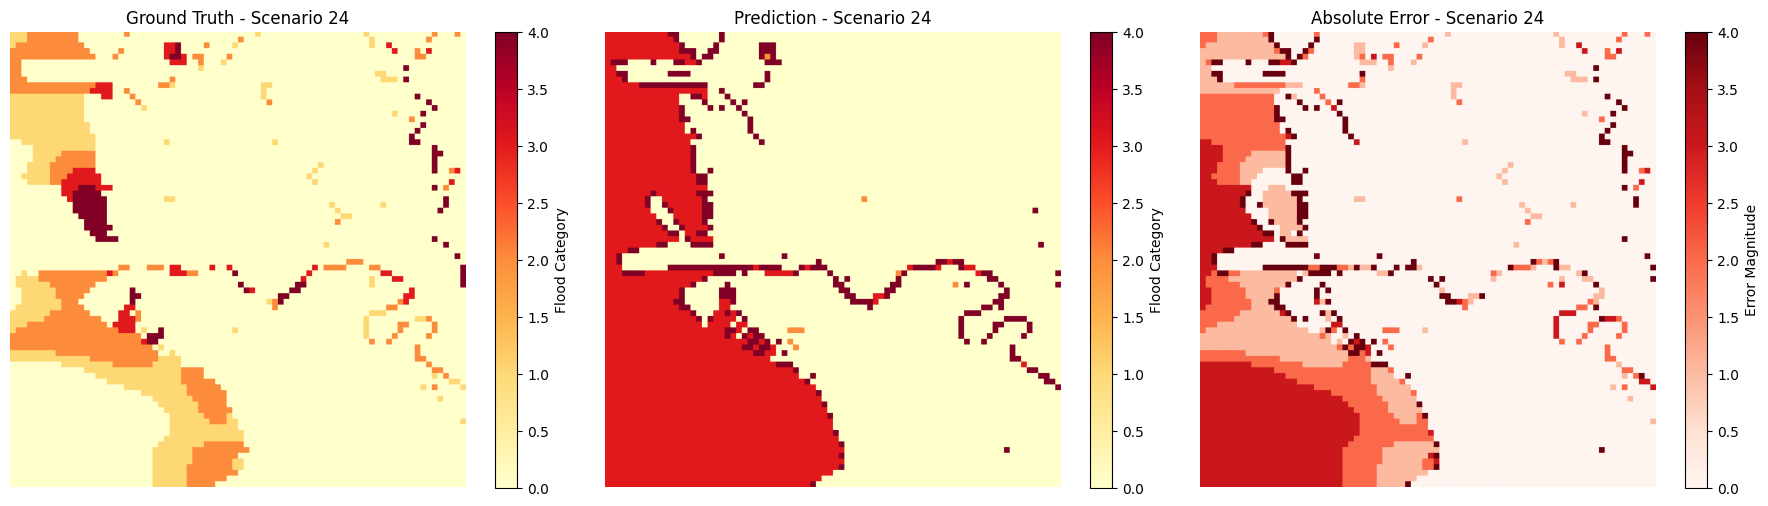


Visualizing Scenario 27...
Confusion matrix saved to results\confusion_matrix_scenario_27.png


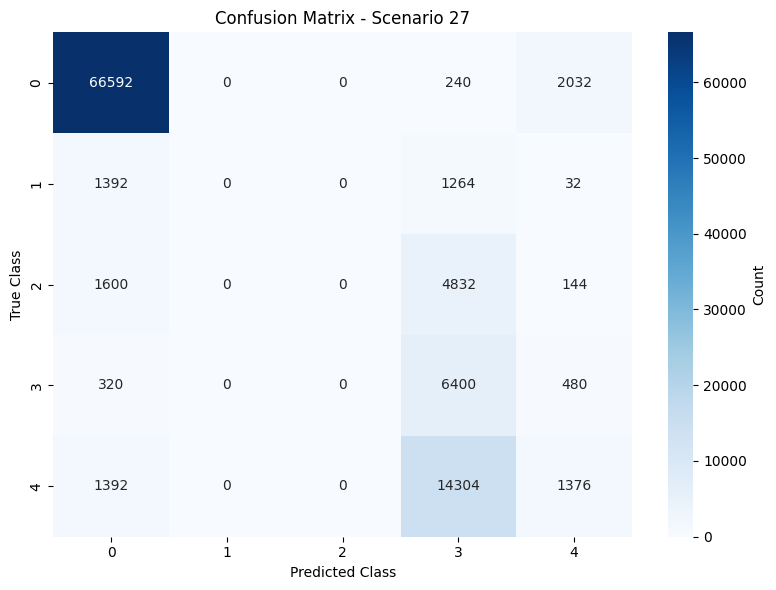

Comparison plot saved to results\comparison_scenario_27.png


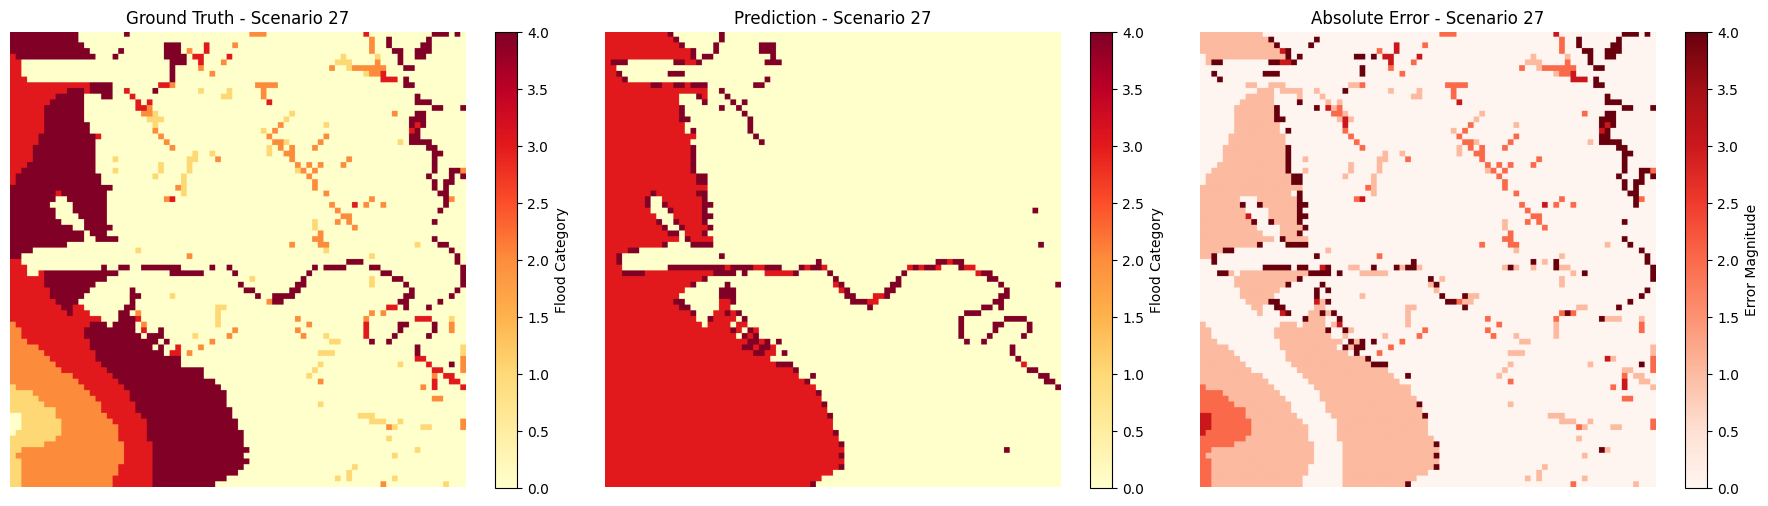


Visualizing Scenario 29...
Confusion matrix saved to results\confusion_matrix_scenario_29.png


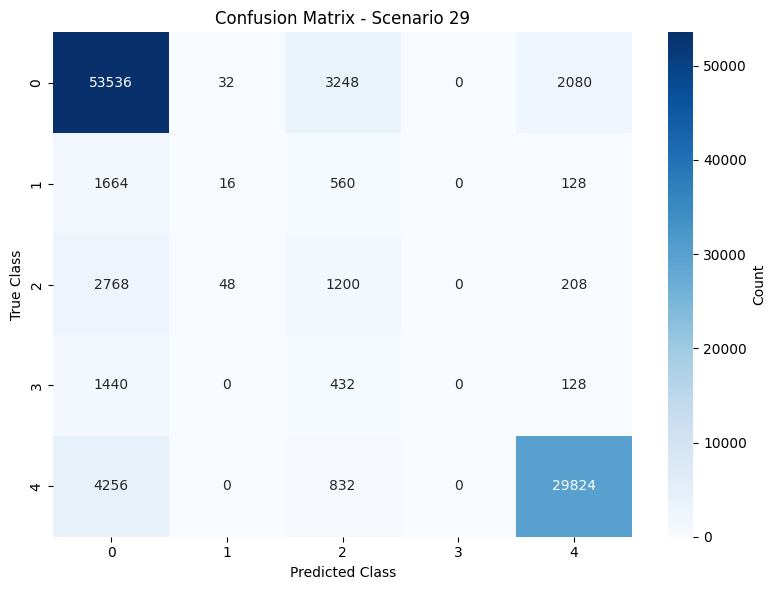

Comparison plot saved to results\comparison_scenario_29.png


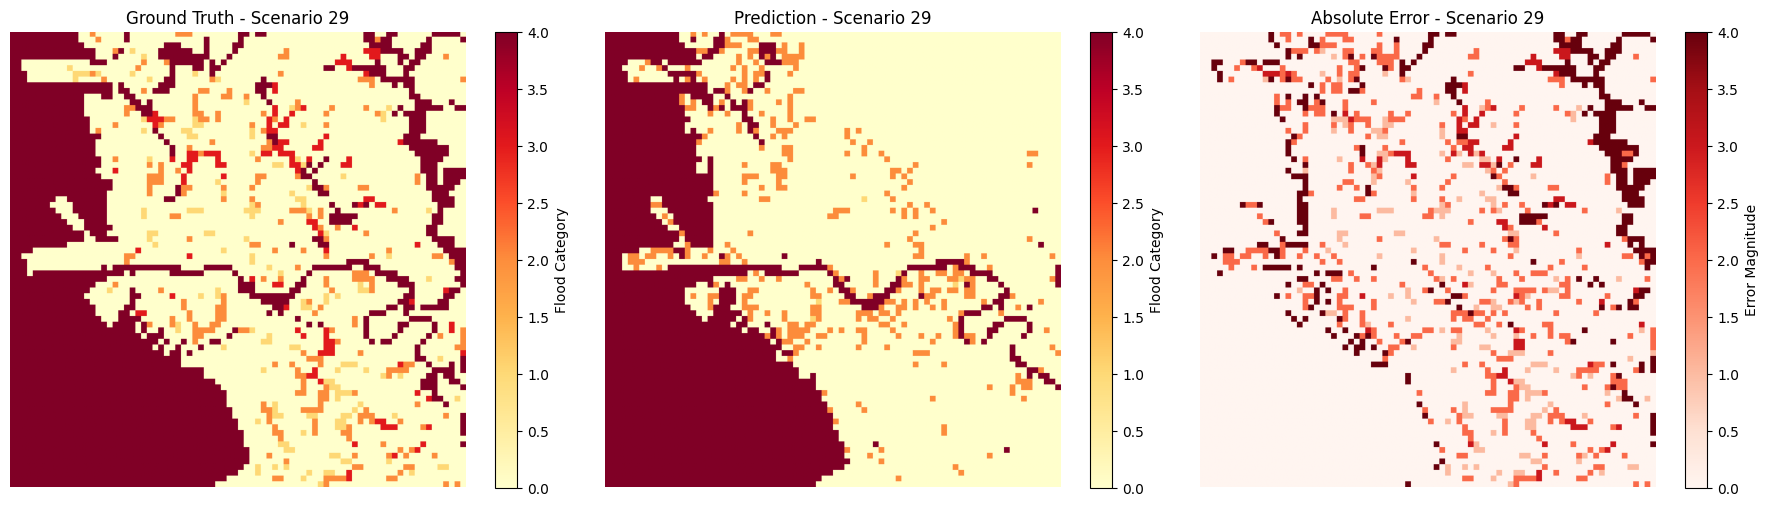


Visualizing Scenario 35...
Confusion matrix saved to results\confusion_matrix_scenario_35.png


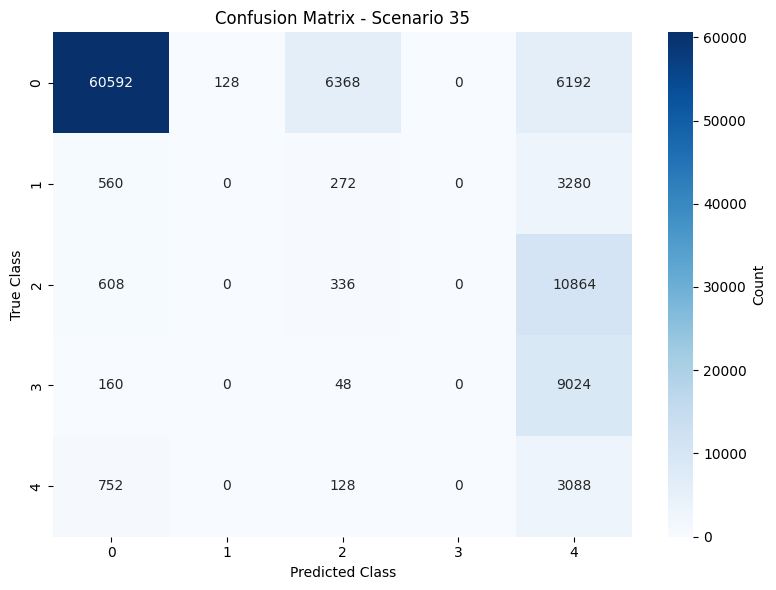

Comparison plot saved to results\comparison_scenario_35.png


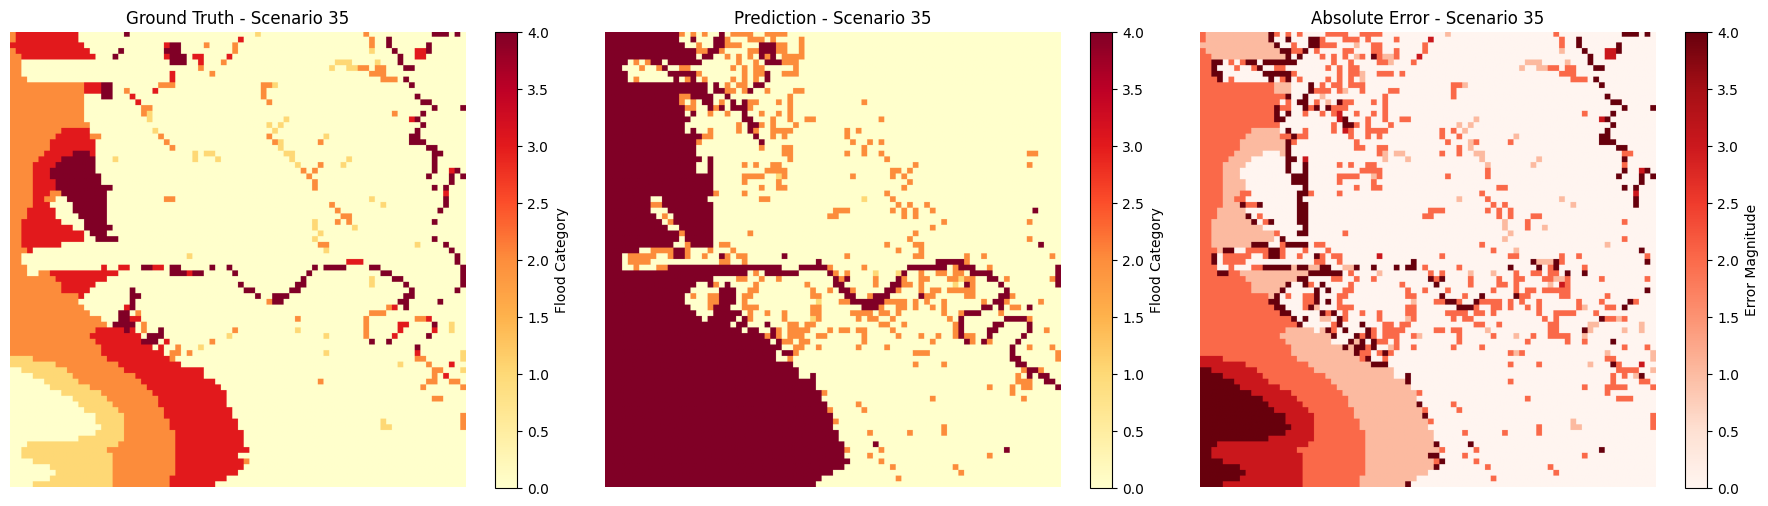


Visualizing Scenario 37...
Confusion matrix saved to results\confusion_matrix_scenario_37.png


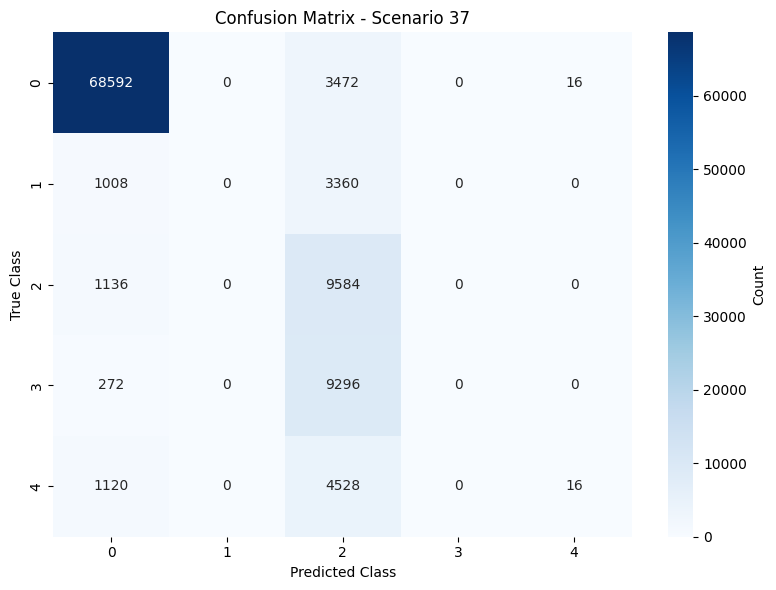

Comparison plot saved to results\comparison_scenario_37.png


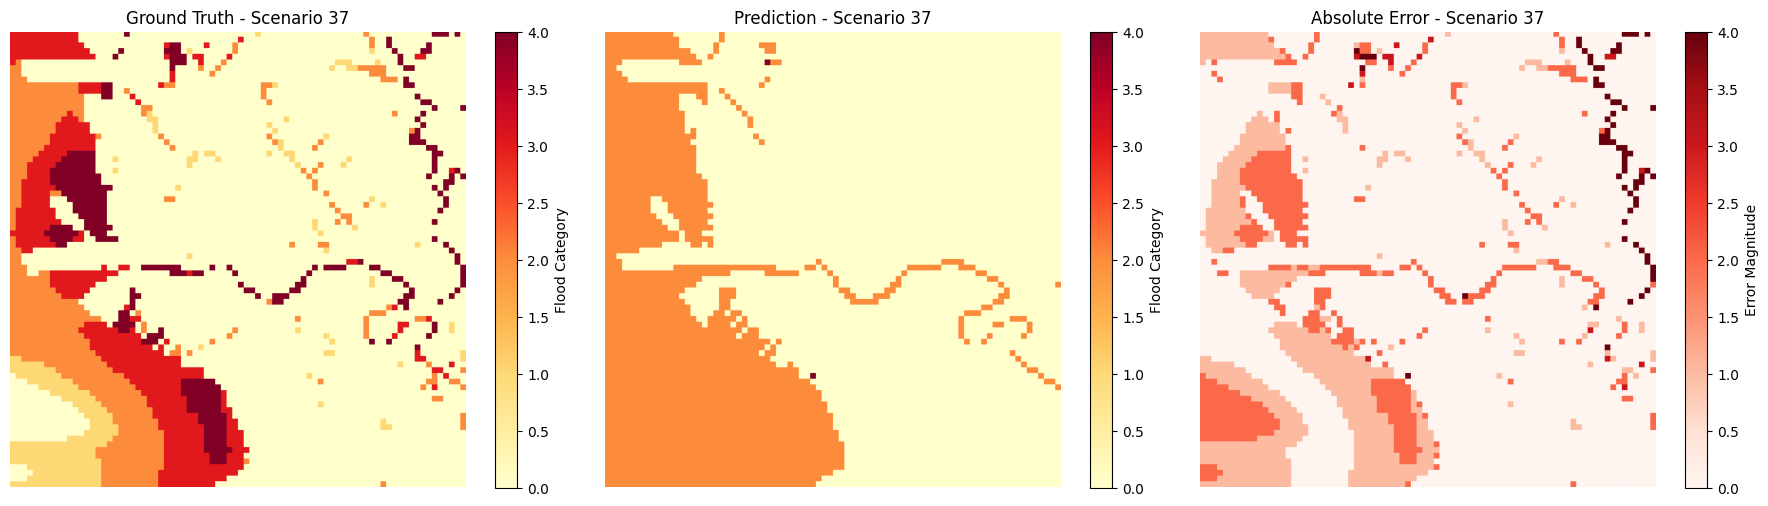


Visualizing Scenario 39...
Confusion matrix saved to results\confusion_matrix_scenario_39.png


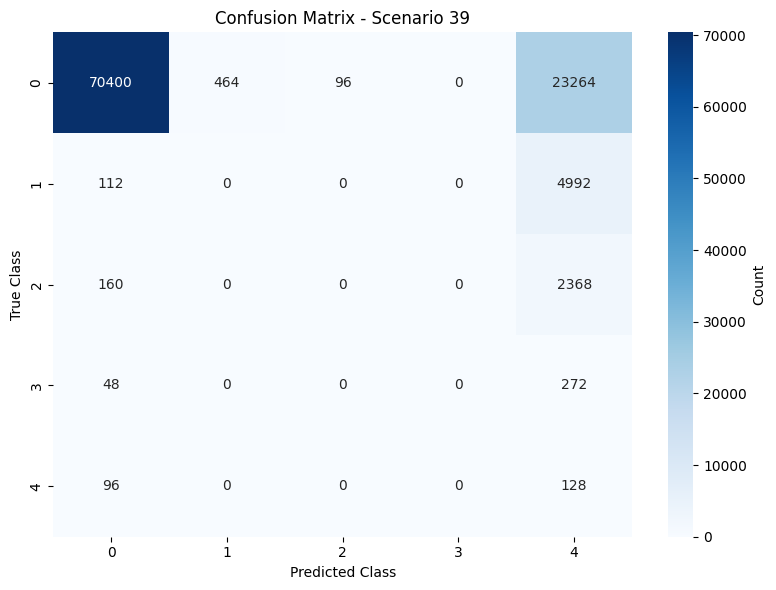

Comparison plot saved to results\comparison_scenario_39.png


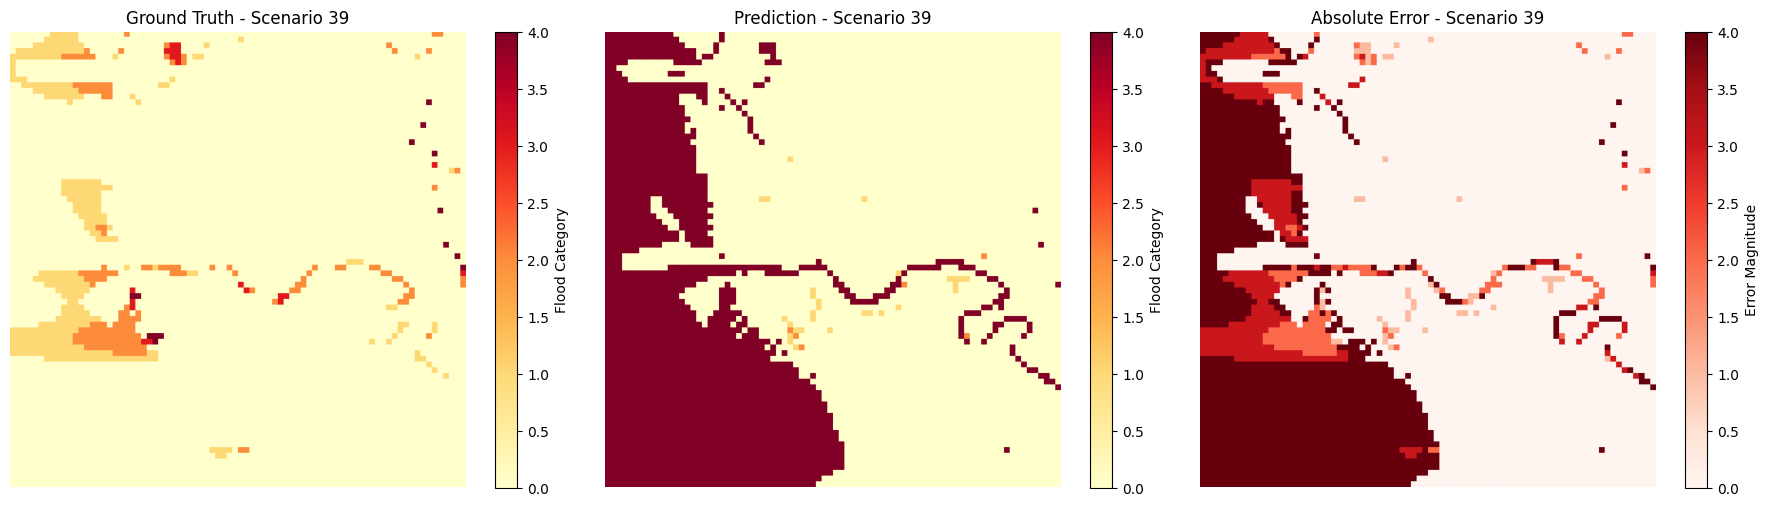


Visualizing Scenario 41...
Confusion matrix saved to results\confusion_matrix_scenario_41.png


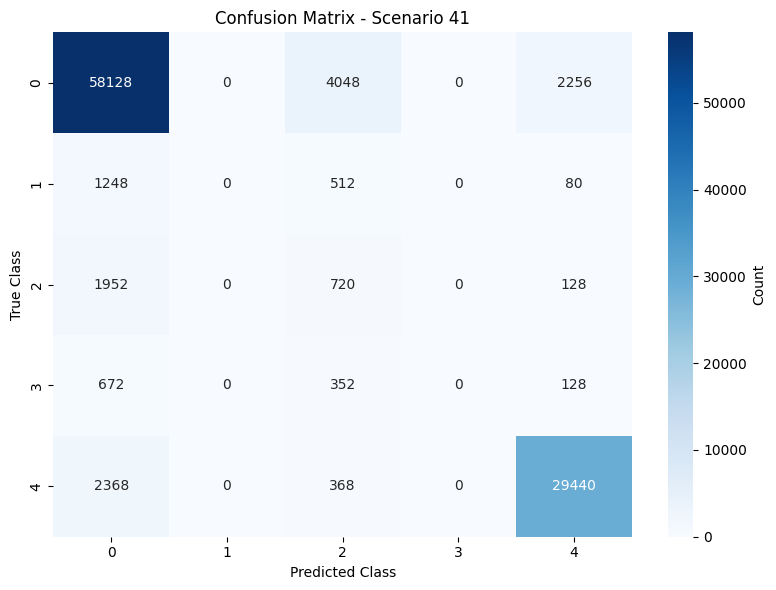

Comparison plot saved to results\comparison_scenario_41.png


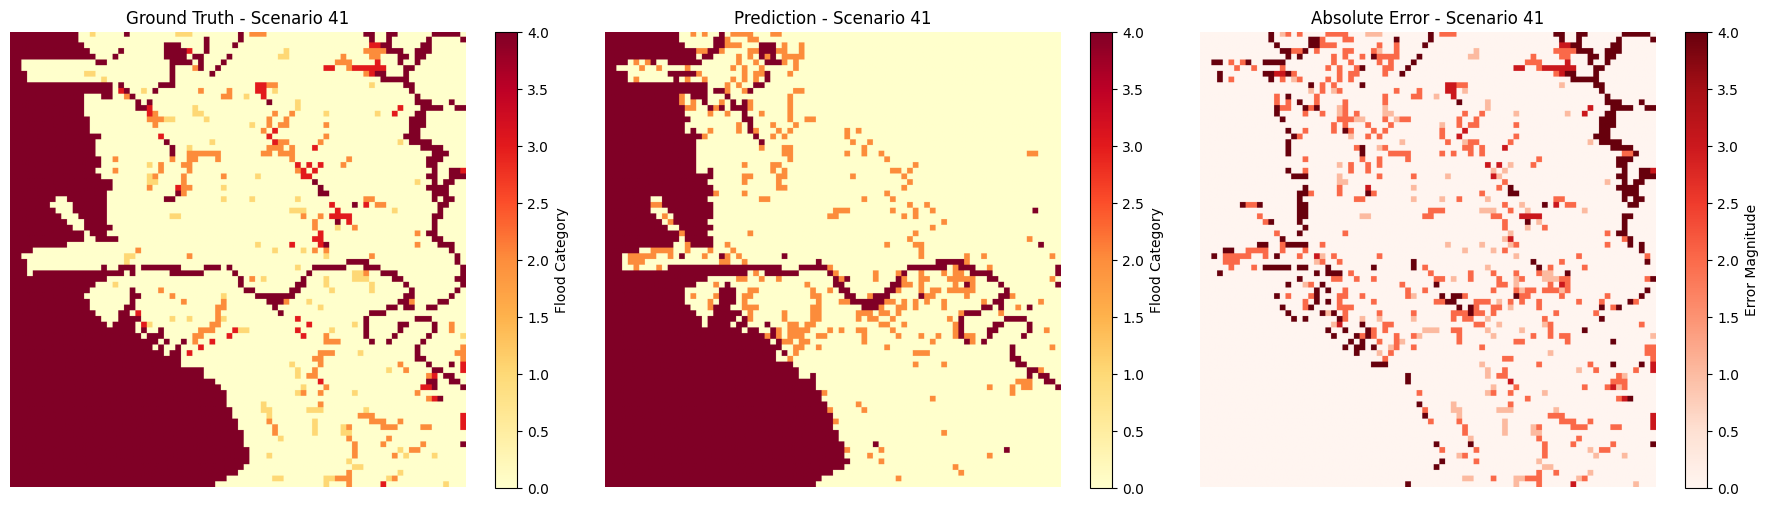


Visualizing Scenario 43...
Confusion matrix saved to results\confusion_matrix_scenario_43.png


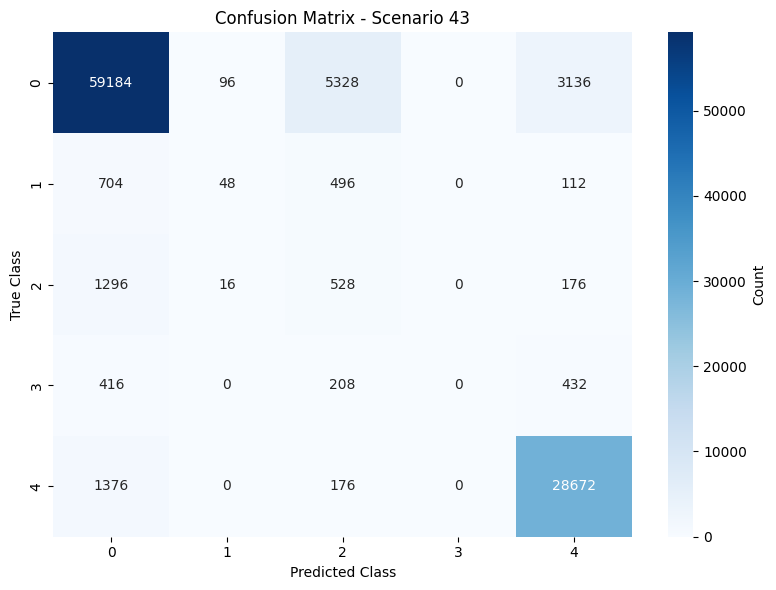

Comparison plot saved to results\comparison_scenario_43.png


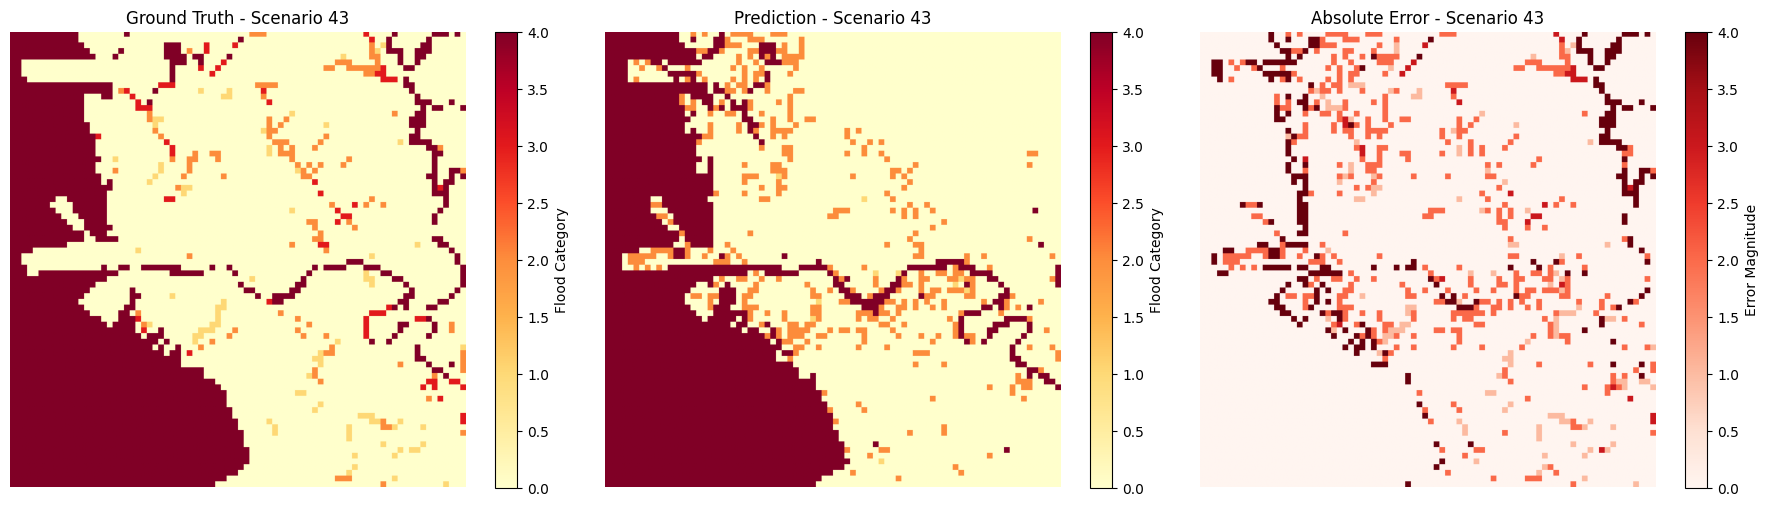


Visualizing Scenario 44...
Confusion matrix saved to results\confusion_matrix_scenario_44.png


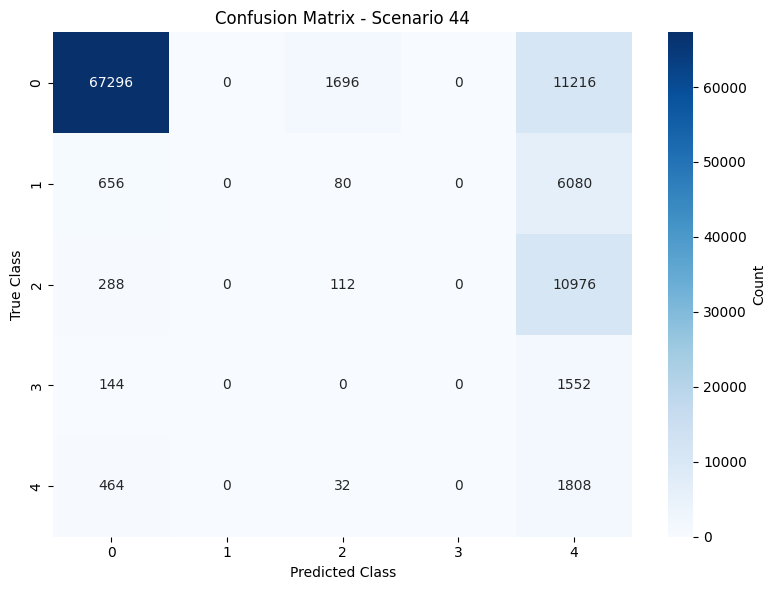

Comparison plot saved to results\comparison_scenario_44.png


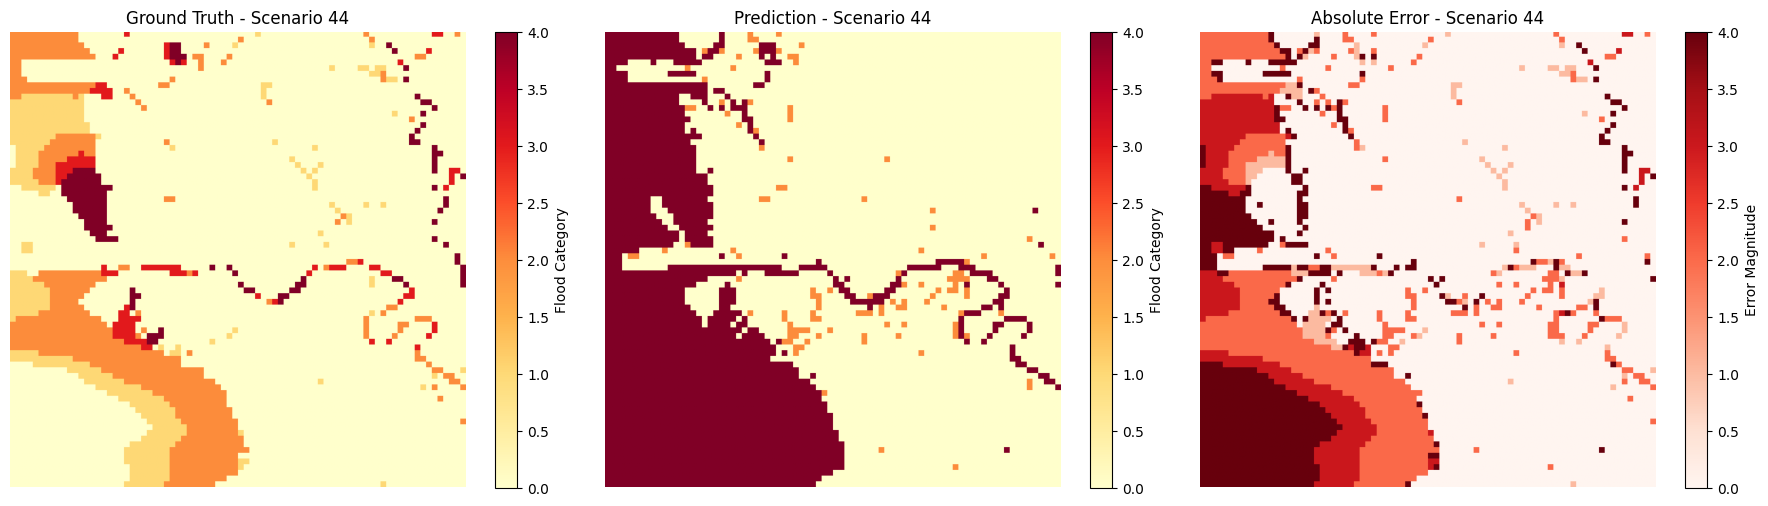


✓ All visualizations generated!

DETAILED TEST RESULTS

SCENARIO 1
Overall Accuracy: 0.5841
Mean IoU (mIoU):  0.1701

Per-Class Metrics:
Class      IoU        Precision    Recall     F1-Score   Support   
----------------------------------------------------------------------
0          0.7852     0.8173       0.9523     0.8797     61104     
1          0.0541     0.0572       0.4947     0.1026     3040      
2          0.0112     0.0227       0.0215     0.0221     5200      
3          0.0000     0.0000       0.0000     0.0000     3120      
4          0.0000     0.0000       0.0000     0.0000     29936     

SCENARIO 4
Overall Accuracy: 0.7252
Mean IoU (mIoU):  0.1983

Per-Class Metrics:
Class      IoU        Precision    Recall     F1-Score   Support   
----------------------------------------------------------------------
0          0.8540     0.9616       0.8842     0.9213     79840     
1          0.1263     0.1285       0.8810     0.2242     4032      
2          0.0114     0.08

In [36]:
print("\nEvaluating all test scenarios...")
all_results, all_predictions = evaluate_test_scenarios(model=model, test_dataset=test_pytorch_dataset, test_scenario_ids=test_scenario_ids, ground_truth_maps=ground_truth_maps, device=device, save_dir='./results')

print("\nGenerating visualizations...")
results_dir = Path('./results')
results_dir.mkdir(parents=True, exist_ok=True)

for scenario_id in test_scenario_ids:
    print(f"\nVisualizing Scenario {scenario_id}...")
    
    # Confusion matrix
    plot_confusion_matrix(metrics=all_results[scenario_id], scenario_id=scenario_id, save_path=results_dir / f'confusion_matrix_scenario_{scenario_id}.png')
    # Ground truth vs prediction
    plot_scenario_comparison(scenario_id=scenario_id, ground_truth_map=ground_truth_maps[scenario_id], predicted_map=all_predictions[scenario_id],save_path=results_dir / f'comparison_scenario_{scenario_id}.png')
print("\n✓ All visualizations generated!")

print("\n" + "="*70)
print("DETAILED TEST RESULTS")
print("="*70)

for scenario_id in test_scenario_ids:
    metrics = all_results[scenario_id]
    
    print(f"\n{'='*70}")
    print(f"SCENARIO {scenario_id}")
    print(f"{'='*70}")
    print(f"Overall Accuracy: {metrics['accuracy']:.4f}")
    print(f"Mean IoU (mIoU):  {metrics['mean_iou']:.4f}")
    
    print("\nPer-Class Metrics:")
    print(f"{'Class':<10} {'IoU':<10} {'Precision':<12} {'Recall':<10} {'F1-Score':<10} {'Support':<10}")
    print("-" * 70)
    
    for class_id in range(5):
        iou = metrics['iou_per_class'][class_id]
        precision = metrics['precision_per_class'][class_id]
        recall = metrics['recall_per_class'][class_id]
        f1 = metrics['f1_per_class'][class_id]
        support = metrics['support_per_class'][class_id]
        
        print(f"{class_id:<10} {iou:<10.4f} {precision:<12.4f} {recall:<10.4f} {f1:<10.4f} {support:<10}")

print("\n" + "="*70)
print("TEST EVALUATION COMPLETE!")
print("="*70)